___
___
# __Impacto de la electrificación del transporte en las emisiones de GEI en Europa__

### 🧩 Librerias necesarias 🧩

Este script requiere las siguientes librerías para funcionar correctamente:
- __os__ (viene con Python, no necesita instalación)
- __pandas__
- __matplotlib__
- __seaborn__
- __plotly__

Si no las tienes instaladas, puedes hacerlo ejecutando el siguiente comando:   
    `pip install pandas matplotlib seaborn plotly`

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
#import plotly.graph_objects as go
from matplotlib.ticker import FuncFormatter

### Configuración del tema visual para las gráficas

Se utiliza un contexto tipo _poster_ (tamaño grande ideal para presentaciones), una paleta de colores brillante, un fondo blanco sin cuadrícula y se eliminan todos los bordes (spines) del gráfico para mantener una estética limpia.

In [2]:
sns.set_theme(context='poster', style='dark', palette='bright')

___
## __Gases de efecto invernadero__

### 📊 Dataset utilizado 📊
__Nombre__: _Greenhouse gas emissions by source sector_ (`env_air_gge`)  
__Fuente oficial__: [Agencia Europea de Medio Ambiente (EEA)](https://www.eea.europa.eu/en)  
__Acceso a los datos__: [Eurostat - Data Browser](https://ec.europa.eu/eurostat/databrowser/view/env_air_gge__custom_17266610/default/table?lang=en)

#### Descripción general del dataset

- Frecuencia temporal: Anual (A)
- Unidad de medida: Miles de toneladas (THS_T)
- Cobertura geográfica: Países de la Unión Europea
- Contaminantes incluidos:
    - Dióxido de carbono (CO2)
    - Óxido nitroso (N2O)
    - Metano (CH4)
    - Hidrofluorocarbonos (HFC)
    - Perfluorocarbonos (PFC)
    - Hexafluoruro de azufre (SF6)
    - Trifluoruro de nitrógeno (NF3)
- Clasificación sectorial: Emisiones agrupadas por sector fuente (transporte, industria, agricultura, etc.)

#### Nota adicional
Este conjunto de datos es ampliamente utilizado para el análisis de emisiones de gases de efecto invernadero en Europa. La clasificación y codificación siguen los estándares de Eurostat para facilitar la interoperabilidad con otras fuentes ambientales.

### 🧭 Carga de datos 🧭

En este paso se carga el archivo Excel que contiene los datos de emisiones de gases de efecto invernadero. El archivo debe estar ubicado en la carpeta `Datasets_crudos`, dentro del directorio principal del proyecto.

In [3]:
file_path = os.path.join(os.getcwd(), "Datasets_crudos", "env_air_gge__custom_15714287_page_spreadsheet.xlsx")

with open(file_path, "rb") as data:
    df_greenhouse_gases = pd.read_excel(data, sheet_name="Data")
df_greenhouse_gases.head(10)

,GEO (Codes),GEO (Labels),TIME,TOTXMEMO,CRF1,CRF1A1,CRF1A2,CRF1A3,CRF1A3A,CRF1A3B,...,CRF1C,CRF1D1,CRF1D2,CRF1D3,CRF2,CRF3,CRF4,CRF5,CRF6,CRF_INDCO2
0,EU27_2020,European Union - 27 countries (from 2020),1990,4649770.44,3741199.78,1442246.90,721407.71,672182.73,11348.39,620116.66,...,NaN,156807.56,0.67,210250.14,450551.75,483165.78,-217472.28,184583.12,NaN,7742.29
1,EU27_2020,European Union - 27 countries (from 2020),1991,4444605.53,3691909.94,1409716.14,678277.58,680852.30,11336.73,629307.69,...,NaN,154118.70,1.14,223185.68,419169.34,455098.05,-316931.49,187794.00,NaN,7565.69
2,EU27_2020,European Union - 27 countries (from 2020),1992,4320714.82,3572830.87,1363222.85,639581.99,702853.18,11603.13,651585.34,...,NaN,159276.13,0.98,221350.93,406060.96,434383.75,-289473.78,189545.26,NaN,7367.76
3,EU27_2020,European Union - 27 countries (from 2020),1993,4226725.66,3514512.39,1311751.92,619343.91,706231.71,11418.36,657461.06,...,NaN,162767.81,0.94,240420.93,396000.85,422919.61,-303318.69,189371.20,NaN,7240.31
4,EU27_2020,European Union - 27 countries (from 2020),1994,4214004.13,3475615.04,1318365.00,617414.61,711670.29,11791.19,663285.15,...,NaN,165812.30,0.86,239770.77,419550.75,417601.43,-294016.11,188156.07,NaN,7096.94
5,EU27_2020,European Union - 27 countries (from 2020),1995,4241086.35,3515882.02,1319044.96,638255.89,724552.50,12735.29,675555.17,...,NaN,168992.17,1.33,245043.95,430774.32,417485.66,-317482.77,187518.72,NaN,6908.40
6,EU27_2020,European Union - 27 countries (from 2020),1996,4304232.58,3607834.63,1347692.67,629649.96,746587.44,13716.39,695553.73,...,NaN,178812.11,1.45,260920.76,430091.94,418660.18,-345282.90,186126.93,NaN,6801.80
7,EU27_2020,European Union - 27 countries (from 2020),1997,4240418.58,3537004.97,1312908.93,620521.47,756319.05,14598.76,705694.39,...,NaN,190717.41,1.96,273032.53,434876.18,416541.18,-337877.07,183186.10,NaN,6687.21
8,EU27_2020,European Union - 27 countries (from 2020),1998,4190637.45,3520962.25,1316028.68,595841.49,785471.28,15345.64,733467.73,...,NaN,200277.02,1.77,276138.01,417962.45,414337.07,-348812.90,179602.65,NaN,6585.93
9,EU27_2020,European Union - 27 countries (from 2020),1999,4102517.04,3470439.18,1278740.27,580718.90,802210.48,16156.48,750389.46,...,NaN,202863.78,1.76,280955.14,399256.84,411903.78,-361543.74,176130.68,NaN,6330.30


### 🔎 Análisis exploratorio de datos (EDA) 🔍

En esta sección se realiza una inspección inicial del dataset crudo, para comprender su estructura, calidad y contenido antes de aplicar transformaciones.

Comprobaré:
- Tipos de datos
- Presencia de valores nulos.
- Duplicados.
- Estadísticas descriptivas básicas.


#### Información general del DataFrame


Países disponibles:
['European Union - 27 countries (from 2020)']

Tipos de datos y resumen general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 31 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   GEO (Codes)   33 non-null     object 
 1   GEO (Labels)  33 non-null     object 
 2   TIME          33 non-null     int64  
 3   TOTXMEMO      33 non-null     float64
 4   CRF1          33 non-null     float64
 5   CRF1A1        33 non-null     float64
 6   CRF1A2        33 non-null     float64
 7   CRF1A3        33 non-null     float64
 8   CRF1A3A       33 non-null     float64
 9   CRF1A3B       33 non-null     float64
 10  CRF1A3B1      33 non-null     float64
 11  CRF1A3B2      33 non-null     float64
 12  CRF1A3B3      33 non-null     float64
 13  CRF1A3B4      33 non-null     float64
 14  CRF1A3B5      33 non-null     float64
 15  CRF1A3C       33 non-null     float64
 16  CRF1A3D       33

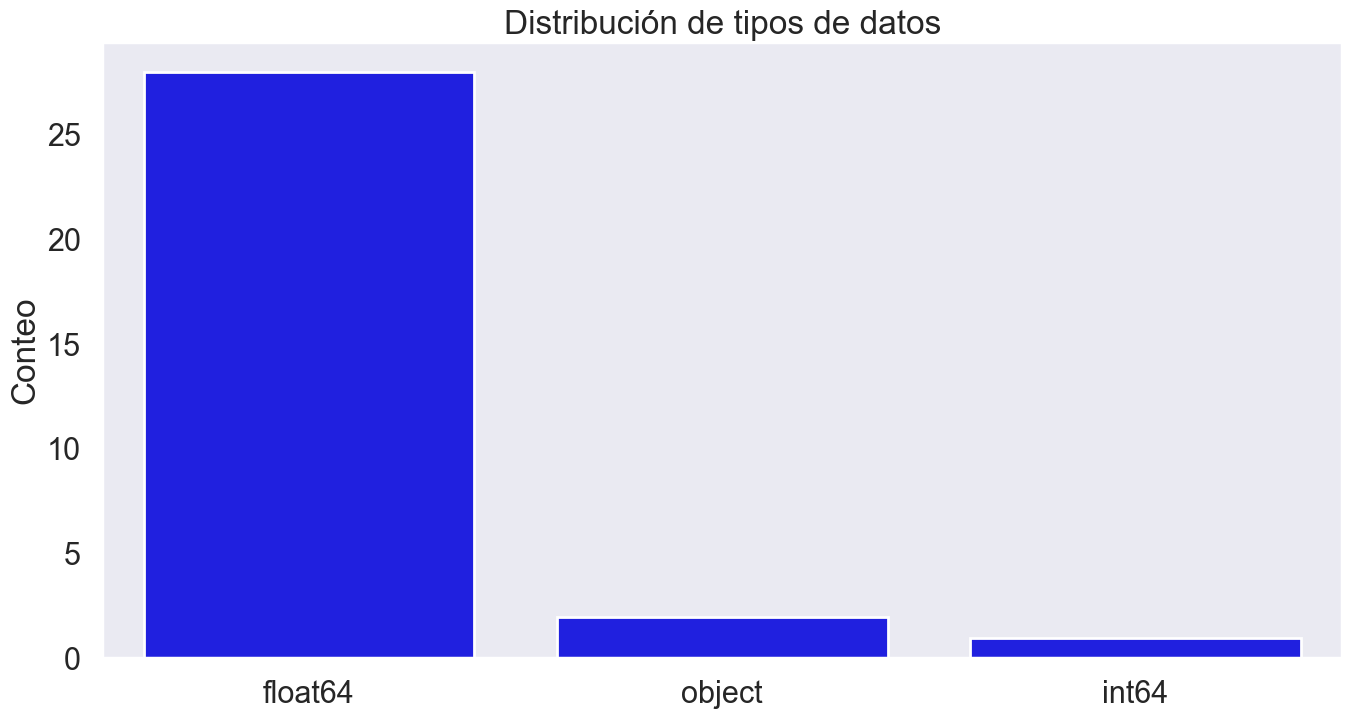

In [11]:
print("\nPaíses disponibles:")
print(df_greenhouse_gases['GEO (Labels)'].unique())

print("\nTipos de datos y resumen general:")
df_greenhouse_gases.info()

dtype_counts = df_greenhouse_gases.dtypes.value_counts().reset_index()
dtype_counts.columns = ['dtype', 'count']

plt.figure(figsize=(16, 8))
sns.barplot(data=dtype_counts, x='dtype', y='count', color='blue')
plt.title("Distribución de tipos de datos")
plt.ylabel("Conteo")
plt.xlabel(None)
plt.show()

#### Nulos por columna

Valores nulos por columna:
CRF1C           33
CRF6            33
GEO (Codes)      0
TOTXMEMO         0
CRF1             0
GEO (Labels)     0
TIME             0
CRF1A3           0
CRF1A3A          0
CRF1A3B          0
CRF1A3B1         0
CRF1A3B2         0
CRF1A3B3         0
CRF1A1           0
CRF1A2           0
CRF1A3B5         0
CRF1A3B4         0
CRF1A3E          0
CRF1A3C          0
CRF1A4           0
CRF1A5           0
CRF1B            0
CRF1A3D          0
CRF1D1           0
CRF1D2           0
CRF2             0
CRF1D3           0
CRF3             0
CRF4             0
CRF5             0
CRF_INDCO2       0
dtype: int64


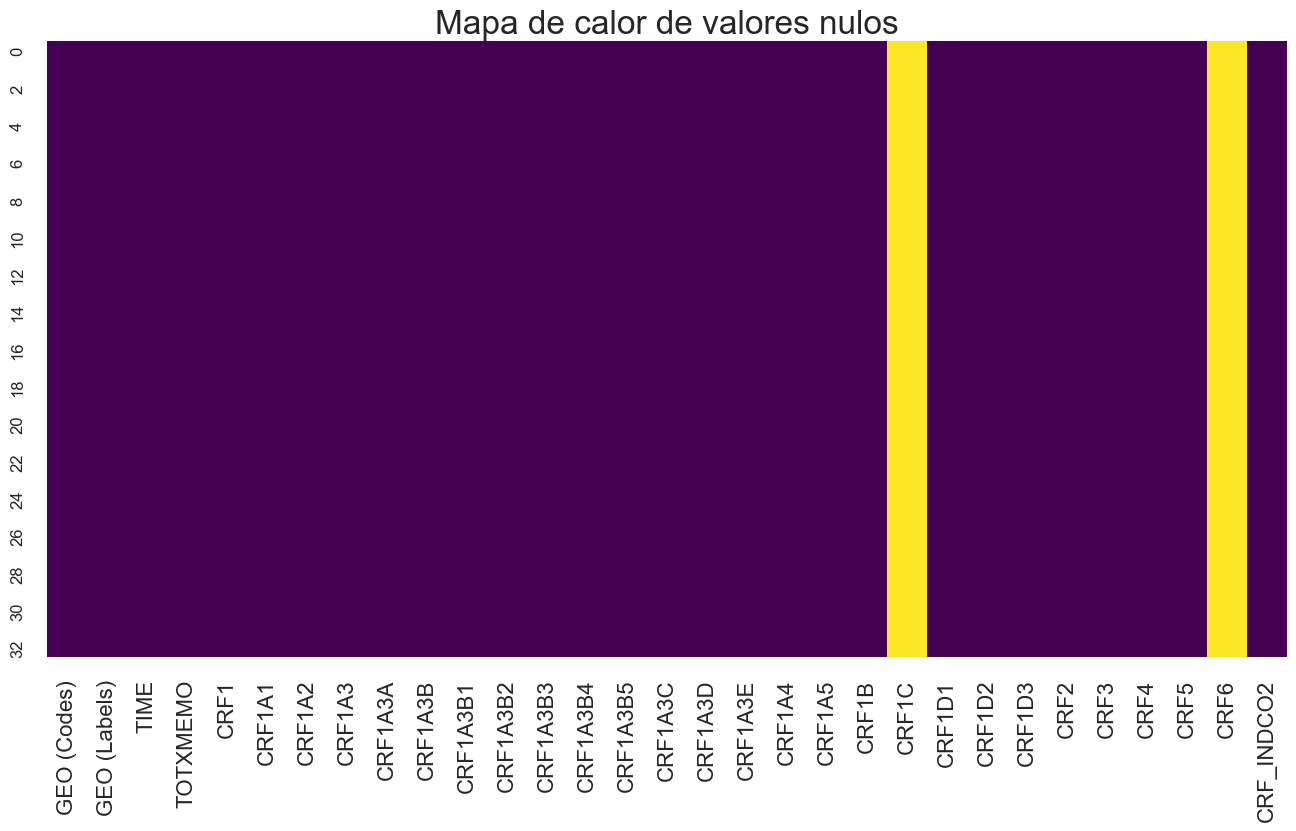

In [12]:
print("Valores nulos por columna:")
print(df_greenhouse_gases.isnull().sum().sort_values(ascending=False))

plt.figure(figsize=(16, 8))
sns.heatmap(df_greenhouse_gases.isnull(), cbar=False, cmap="viridis")
plt.title("Mapa de calor de valores nulos")
plt.xticks(fontsize=16)
plt.yticks(fontsize=12)
plt.show()

#### Duplicados

In [13]:
print(f"Total de filas duplicadas: {df_greenhouse_gases.duplicated().sum()}")

Total de filas duplicadas: 0


#### Estadísticas descriptivas básicas

In [14]:
print("Estadísticas básicas (variables numéricas):")
print(df_greenhouse_gases.describe())

Estadísticas básicas (variables numéricas):
             TIME      TOTXMEMO          CRF1        CRF1A1         CRF1A2  \
count    33.00000  3.300000e+01  3.300000e+01  3.300000e+01      33.000000   
mean   2006.00000  3.914869e+06  3.286780e+06  1.232305e+06  525402.723636   
std       9.66954  4.180233e+05  3.478174e+05  1.800467e+05   93301.976136   
min    1990.00000  3.052044e+06  2.489953e+06  7.784605e+05  392585.980000   
25%    1998.00000  3.553809e+06  2.970429e+06  1.113713e+06  431409.860000   
50%    2006.00000  4.141954e+06  3.470439e+06  1.311752e+06  549172.570000   
75%    2014.00000  4.214004e+06  3.537005e+06  1.352481e+06  595841.490000   
max    2022.00000  4.649770e+06  3.741200e+06  1.442247e+06  721407.710000   

              CRF1A3       CRF1A3A        CRF1A3B       CRF1A3B1  \
count      33.000000     33.000000      33.000000      33.000000   
mean   786639.417273  14154.645758  740249.796061  452743.134242   
std     52649.243759   2252.595733   53009.985277

### 🛠️ Transformaciones de columnas 🛠️

Se agregan y transforman columnas a partir de otras variables presentes en el dataset original para facilitar el análisis posterior.

En concreto:

1. **`CRF1C` (_Transporte y almacenamiento de CO₂_) y `CRF6` (_Otros sectores_)**  
   Se eliminan porque están completamente vacías en este dataset y no aportan información útil al análisis.

2. **`CRF1D` (_Ítems informativos_)**  
   Se crea una nueva columna combinando las subcategorías `CRF1D1`, `CRF1D2` y `CRF1D3`. Luego se eliminan estas columnas originales para evitar redundancia.

3. **`CRF1NMEMO` (_Energía con ítems informativos_)**  
   Suma de `CRF1` (energía) y `CRF1D` (ítems informativos), para obtener una visión más completa de las emisiones del sector energético.

4. **`TOTNMEMO` (_Total con ítems informativos_)**  
   Combinación de `TOTXMEMO` y `CRF1D`, integrando así componentes que suelen excluirse del total base.

5. **`CRF1A` (_Combustión por sector_)**  
   Suma de las subcategorías de combustión (`CRF1A1` a `CRF1A5`) para analizar el total de emisiones por este tipo de fuente.

6. **Renombrado de columnas**  
   Las columnas se renombran a nombres más descriptivos y amigables para el análisis.

#### Eliminar columnas sin valor informativo

In [4]:
# Eliminamos las columnas 'CRF1C' y 'CRF6' porque contienen solo valores nulos
df_greenhouse_gases.drop(labels=['CRF1C', 'CRF6'], axis=1, inplace=True)

# Eliminar columna de etiquetas geográficas (ya codificadas)
df_greenhouse_gases = df_greenhouse_gases.drop(labels=['GEO (Labels)'], axis=1)

#### Crear nuevas columnas a partir de subcategorías

In [5]:
# Crear 'CRF1D' como suma de subcategorías informativas
df_greenhouse_gases['CRF1D'] = df_greenhouse_gases[['CRF1D1', 'CRF1D2', 'CRF1D3']].sum(axis=1).round(2)
df_greenhouse_gases.insert(22, 'CRF1D', df_greenhouse_gases.pop('CRF1D'))

# Eliminar subcolumnas originales de ítems informativos
df_greenhouse_gases.drop(labels=['CRF1D1', 'CRF1D2', 'CRF1D3'], axis=1, inplace=True)

# Crear 'CRF1NMEMO': Energía incluyendo ítems informativos
df_greenhouse_gases['CRF1NMEMO'] = df_greenhouse_gases[['CRF1', 'CRF1D']].sum(axis=1).round(2)
df_greenhouse_gases.insert(4, 'CRF1NMEMO', df_greenhouse_gases.pop('CRF1NMEMO'))

# Crear 'TOTNMEMO': Total incluyendo ítems informativos
df_greenhouse_gases['TOTNMEMO'] = df_greenhouse_gases[['TOTXMEMO', 'CRF1D']].sum(axis=1).round(2)
df_greenhouse_gases.insert(3, 'TOTNMEMO', df_greenhouse_gases.pop('TOTNMEMO'))

# Crear 'CRF1A': Combustión por sector (suma de subcategorías CRF1A1 a CRF1A5)
df_greenhouse_gases['CRF1A'] = df_greenhouse_gases[['CRF1A1', 'CRF1A2', 'CRF1A3', 'CRF1A4', 'CRF1A5']].sum(axis=1).round(2)
df_greenhouse_gases.insert(7, 'CRF1A', df_greenhouse_gases.pop('CRF1A'))

#### Renombrar y limpiar nombres de columnas

In [ ]:
# Renombrar columnas a nombres más descriptivos
df_greenhouse_gases = df_greenhouse_gases.rename(columns={
    'GEO_(Codes)':'Geocodificación',
    'TIME':'Años',
    'TOTNMEMO':'Total (con informativos)',
    'TOTXMEMO':'Total (sin informativos)', 
    'CRF1NMEMO':'Energía (con informativos)',
    'CRF1':'Energía',
    'CRF1A':'Combustión por sector',
    'CRF1A1':'Combustión en las industrias energéticas',
    'CRF1A2':'Combustión en manufactura y construcción',
    'CRF1A3':'Combustión en el transporte',
    'CRF1A3A':'Combustión en la aviación nacional',
    'CRF1A3B':'Combustión en el transporte por carretera',
    'CRF1A3B1':'Combustión en automóviles',
    'CRF1A3B2':'Combustión en camiones ligeros',
    'CRF1A3B3':'Combustión en camiones pesados ​​y autobuses',
    'CRF1A3B4':'Combustión en motocicletas',
    'CRF1A3B5':'Combustión en otros transportes por carretera',
    'CRF1A3C':'Combustión en ferrocarriles',
    'CRF1A3D':'Combustión en la navegación interior',
    'CRF1A3E':'Combustión en otros transportes',
    'CRF1A4':'Otros sectores de combustión',
    'CRF1A5':'Otros sectores de combustión n.c.p.',
    'CRF1B':'Combustibles  emisiones fugitivas',
    'CRF1D':'Ítems informativos',
    'CRF2':'Procesos y productos industriales',
    'CRF3':'Agricultura',
    'CRF4':'Uso del suelo y silvicultura (UTCUTS)',
    'CRF5':'Gestión de residuos',
    'CRF_INDCO2':'CO2 indirecto'})

# Estandarizar nombres de columnas: reemplazar espacios por guiones bajos
df_greenhouse_gases.columns = df_greenhouse_gases.columns.str.strip().str.replace(' ', '_')

# Vista previa del dataframe
df_greenhouse_gases.head(10)

,GEO_(Codes),Años,Total_(sin_informativos),Total_(con_informativos),Energía,Energía_(con_informativos),Combustión_en_las_industrias_energéticas,Combustión_por_sector,Combustión_en_manufactura_y_construcción,Combustión_en_el_transporte,...,Combustión_en_otros_transportes,Otros_sectores_de_combustión,Otros_sectores_de_combustión_n.c.p.,Combustibles__emisiones_fugitivas,Ítems_informativos,Procesos_y_productos_industriales,Agricultura,Uso_del_suelo_y_silvicultura_(UTCUTS),Gestión_de_residuos,CO2_indirecto
0,EU27_2020,1990,4649770.44,5016828.81,3741199.78,4108258.15,1442246.90,3572188.74,721407.71,672182.73,...,6141.59,713922.78,22428.62,169011.05,367058.37,450551.75,483165.78,-217472.28,184583.12,7742.29
1,EU27_2020,1991,4444605.53,4821911.05,3691909.94,4069215.46,1409716.14,3536128.91,678277.58,680852.30,...,6324.25,748535.02,18747.87,155781.04,377305.52,419169.34,455098.05,-316931.49,187794.00,7565.69
2,EU27_2020,1992,4320714.82,4701342.86,3572830.87,3953458.91,1363222.85,3421824.83,639581.99,702853.18,...,6131.60,701094.02,15072.79,151006.04,380628.04,406060.96,434383.75,-289473.78,189545.26,7367.76
3,EU27_2020,1993,4226725.66,4629915.34,3514512.39,3917702.07,1311751.92,3364372.32,619343.91,706231.71,...,5493.29,714650.26,12394.52,150140.07,403189.68,396000.85,422919.61,-303318.69,189371.20,7240.31
4,EU27_2020,1994,4214004.13,4619588.06,3475615.04,3881198.97,1318365.00,3329642.10,617414.61,711670.29,...,5034.39,670792.63,11399.57,145972.94,405583.93,419550.75,417601.43,-294016.11,188156.07,7096.94
5,EU27_2020,1995,4241086.35,4655123.80,3515882.02,3929919.47,1319044.96,3370620.77,638255.89,724552.50,...,5906.94,678348.31,10419.11,145261.25,414037.45,430774.32,417485.66,-317482.77,187518.72,6908.40
6,EU27_2020,1996,4304232.58,4743966.90,3607834.63,4047568.95,1347692.67,3466549.63,629649.96,746587.44,...,6545.98,733239.79,9379.77,141285.00,439734.32,430091.94,418660.18,-345282.90,186126.93,6801.80
7,EU27_2020,1997,4240418.58,4704170.48,3537004.97,4000756.87,1312908.93,3391012.98,620521.47,756319.05,...,5998.12,691363.18,9900.35,145991.99,463751.90,434876.18,416541.18,-337877.07,183186.10,6687.21
8,EU27_2020,1998,4190637.45,4667054.25,3520962.25,3997379.05,1316028.68,3382777.75,595841.49,785471.28,...,6144.18,675184.92,10251.38,138184.49,476416.80,417962.45,414337.07,-348812.90,179602.65,6585.93
9,EU27_2020,1999,4102517.04,4586337.72,3470439.18,3954259.86,1278740.27,3334086.79,580718.90,802210.48,...,6390.60,663222.49,9194.65,136352.39,483820.68,399256.84,411903.78,-361543.74,176130.68,6330.30


#### 💾 Exportación del dataset limpio 💾

El DataFrame transformado se guarda como archivo `.csv` en la carpeta `Datasets_procesados`. Esto permite reutilizar los datos ya procesados sin volver a ejecutar todos los pasos anteriores.

In [18]:
# Crear la ruta de exportación
output_dir = os.path.join(os.getcwd(), "Datasets_procesados")
os.makedirs(output_dir, exist_ok=True)  # Para crear la carpeta si no existe

# Ruta final del archivo
output_path = os.path.join(output_dir, "df_greenhouse_gases.csv")

# Guardar el archivo
df_greenhouse_gases.to_csv(output_path, index=False, encoding='utf-8')

### Visualizaciones exploratorias.

#### ¿Cómo han evolucionado las emisiones de gases de efecto invernadero (GEI) a lo largo del tiempo?

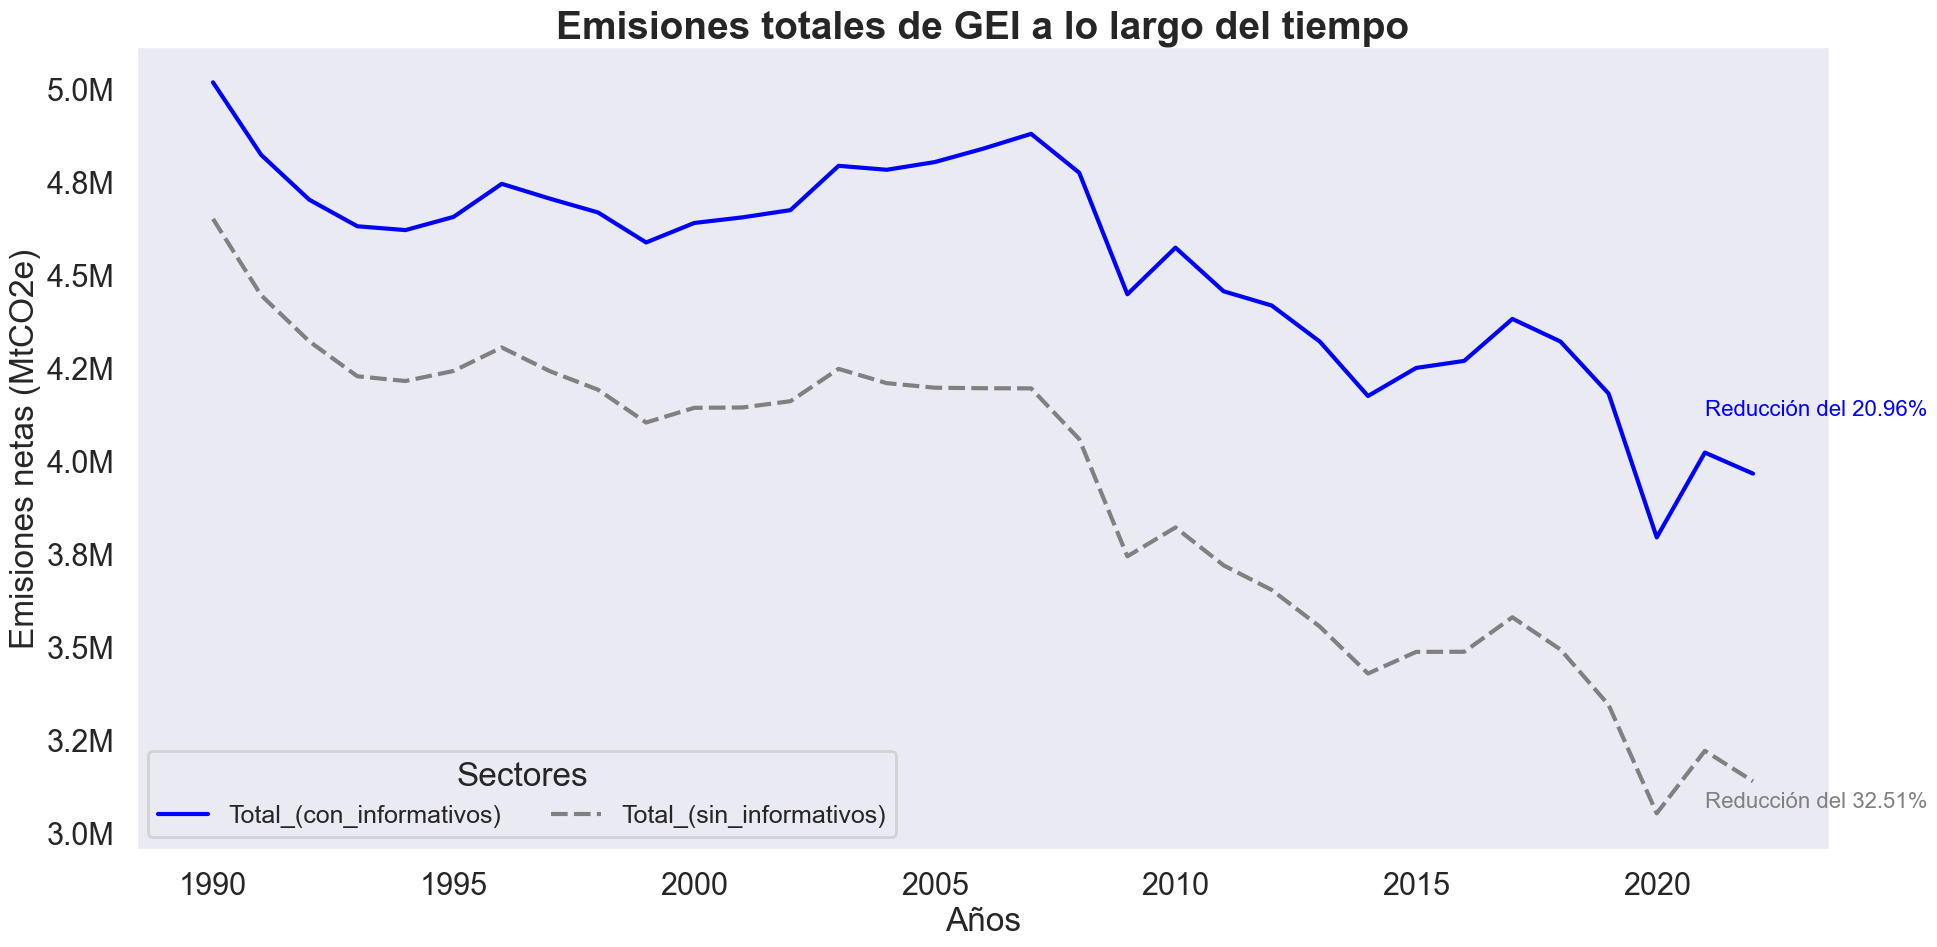

In [13]:
# Cálculo de la evolución de las emisiones de GEI.
emisiones_1990 = df_greenhouse_gases[df_greenhouse_gases['Años'] == 1990]
emisiones_2022 = df_greenhouse_gases[df_greenhouse_gases['Años'] == 2022]

abs_red_con = emisiones_1990['Total_(con_informativos)'].values[0] - emisiones_2022['Total_(con_informativos)'].values[0]
pct_red_con = abs_red_con / emisiones_1990['Total_(con_informativos)'].values[0] * 100

abs_red_sin = emisiones_1990['Total_(sin_informativos)'].values[0] - emisiones_2022['Total_(sin_informativos)'].values[0]
pct_red_sin = abs_red_sin / emisiones_1990['Total_(sin_informativos)'].values[0] * 100


# Gráfico de la evolución de las emisiones de GEI.
id_var = ['Años']
value_vars = ['Total_(con_informativos)',
              'Total_(sin_informativos)']
df_ghg_long = df_greenhouse_gases.melt(id_vars=id_var, value_vars=value_vars, var_name='Sectores', value_name='Emisiones')

plt.figure(figsize=(20, 10))
ax = sns.lineplot(
    data=df_ghg_long,
    x='Años',
    y='Emisiones',
    hue='Sectores',
    style='Sectores',
    palette=['blue', 'gray'])
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
plt.legend(
    title='Sectores', loc='lower left',
    ncol=2, fontsize=18)
plt.title(
    'Emisiones totales de GEI a lo largo del tiempo',
    fontdict={'fontsize':28, 'fontweight':'bold'})
plt.ylabel('Emisiones netas (MtCO2e)')

# 🔵 Texto sobre las emisiones con informativos
x_text_1 = 2021
y_text_1 = df_ghg_long.query("Años == @x_text_1 and Sectores == 'Total_(con_informativos)'")['Emisiones'].values[0]
ax.text(x_text_1, y_text_1 + 1e5, f'Reducción del {pct_red_con:.2f}%', color='blue', fontsize=16)

# ⚫ Texto sobre las emisiones sin informativos
x_text_2 = 2021
y_text_2 = df_ghg_long.query("Años == @x_text_2 and Sectores == 'Total_(sin_informativos)'")['Emisiones'].values[0]
ax.text(x_text_2, y_text_2 - 1.5e5, f'Reducción del {pct_red_sin:.2f}%', color='gray', fontsize=16)

plt.tight_layout()
plt.show()

Para el año 2022 las emisiones totales con ítems informativos se redujeron en un 20.96% y sin los ítems en un 32.51%, respecto a sus valores desde 1990.

#### ¿Qué sectores contribuyen más a las emisiones de GEI y cómo ha cambiado su participación a lo largo del tiempo?

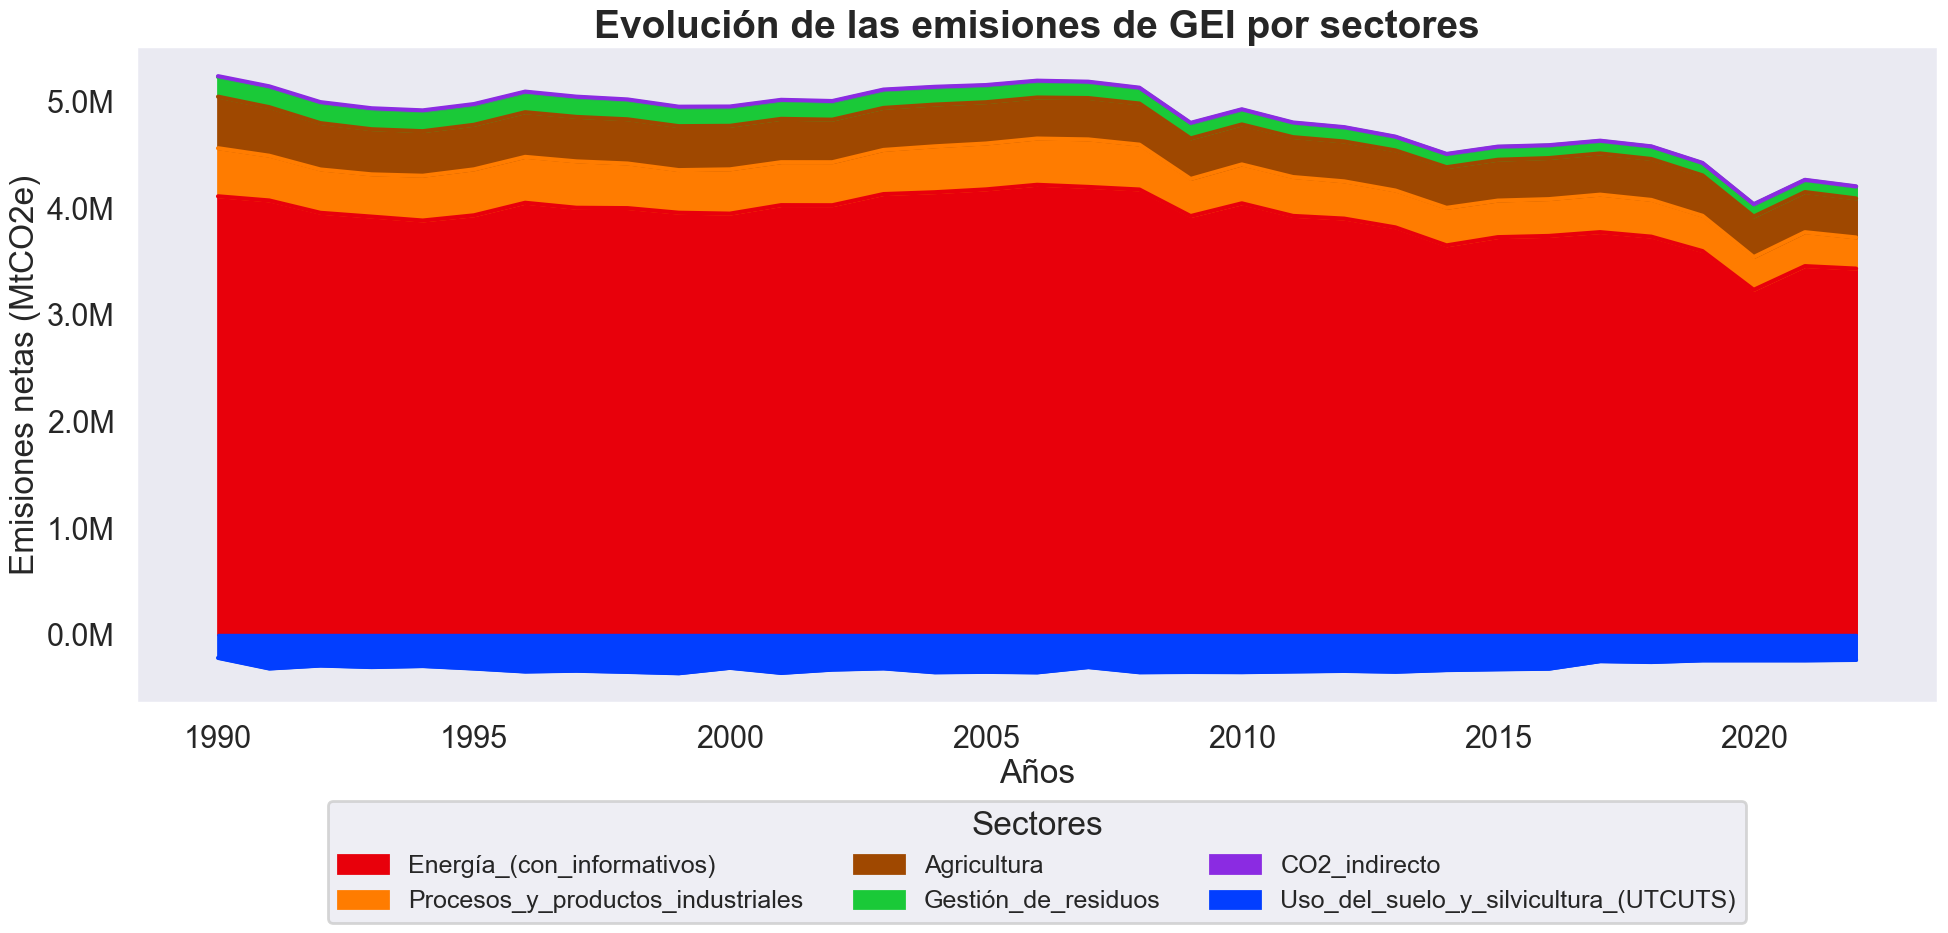

In [51]:
df_greenhouse_gases_by_sectors = df_greenhouse_gases[[
    'Años',
    'Energía_(con_informativos)',
    'Procesos_y_productos_industriales',
    'Agricultura',
    'Gestión_de_residuos',
    'CO2_indirecto',
    'Uso_del_suelo_y_silvicultura_(UTCUTS)']]
df_greenhouse_gases_by_sectors = df_greenhouse_gases_by_sectors.set_index('Años')

custom_colors = {
    'Energía_(con_informativos)': '#e8000b',
    'Procesos_y_productos_industriales': '#ff7c00',
    'Agricultura': '#9f4800',
    'Gestión_de_residuos': '#1ac938',
    'CO2_indirecto': '#8b2be2',
    'Uso_del_suelo_y_silvicultura_(UTCUTS)': '#023eff'}

ax = df_greenhouse_gases_by_sectors.plot(
    kind='area',
    stacked=True,
    figsize=(20, 10),
    color=custom_colors)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
plt.legend(
    title='Sectores', loc='upper center',
    ncol=3, fontsize=18, bbox_to_anchor=(0.5, -0.13))
plt.title(
    'Evolución de las emisiones de GEI por sectores',
    fontdict={'fontsize':28, 'fontweight':'bold'})
plt.ylabel('Emisiones netas (MtCO2e)')
plt.tight_layout()
plt.show()

#### Emisiones en el sector Energías

In [43]:
df_2022 = df_greenhouse_gases[df_greenhouse_gases['Años'] == 2022]

# Categorías directas de "Energía" (nivel 2)
energy_categories = {
    'Combustibles__emisiones_fugitivas': 'Energía',
    'Ítems_informativos': 'Energía'}

# Subcategorías bajo "Combustión por sector" (nivel 3)
combustion_subcategories = {
    'Combustión_en_el_transporte': 'Combustión por sector',
    'Combustión_en_las_industrias_energéticas': 'Combustión por sector',
    'Combustión_en_manufactura_y_construcción': 'Combustión por sector',
    'Otros_sectores_de_combustión': 'Combustión por sector',
    'Otros_sectores_de_combustión_n.c.p.': 'Combustión por sector'}

# Construcción de registros jerárquicos
data_rows = []

# Nivel 2: Categorías directas de energías
for col, parent in energy_categories.items():
    value = df_2022[col].values[0]
    data_rows.append({
        'Nivel1': parent,
        'Nivel2': col,
        'Nivel3': None,
        'Emisiones': value})

# Nivel 3: Subcategorías de combustión
for col, parent in combustion_subcategories.items():
    value = df_2022[col].values[0]
    data_rows.append({
        'Nivel1': 'Energía',
        'Nivel2': parent,
        'Nivel3': col,
        'Emisiones': value})

# Crear DataFrame
df_plot = pd.DataFrame(data_rows)

# Mapeo de nombres más amigables
rename_map = {
    'Combustión_en_el_transporte': 'Transporte',
    'Combustión_en_las_industrias_energéticas': 'Industrias energéticas',
    'Combustión_en_manufactura_y_construcción': 'Manufactura y construcción',
    'Otros_sectores_de_combustión': 'Otros sectores de combustión',
    'Otros_sectores_de_combustión_n.c.p.': 'Otros sectores n.c.p.',
    'Combustibles__emisiones_fugitivas': 'Emisiones fugitivas',
    'Ítems_informativos': 'Ítems informativos'}
df_plot.replace(rename_map, inplace=True)

fig = px.treemap(
    df_plot,
    path=['Nivel1', 'Nivel2', 'Nivel3'],
    values='Emisiones',
    color='Emisiones',
    color_continuous_scale='Portland',
    title='Distribución jerárquica de emisiones en el sector Energía (2022)')

fig.update_layout(
    width=1600,
    height=900,
    margin=dict(t=60, l=20, r=20, b=20),
    font=dict(size=18, color="black"),
    title=dict(
        font=dict(size=28, color="black", weight=800),
        x=0.5, xanchor="center"))

fig.show()

#### Emisiones por la quema de combustibles en el transporte

In [44]:
df_2022 = df_greenhouse_gases[df_greenhouse_gases['Años'] == 2022]

# Categorías directas de "Transporte" (nivel 2)
transport_categories = {
    'Combustión_en_la_aviación_nacional': 'Transporte',
    'Combustión_en_ferrocarriles': 'Transporte',
    'Combustión_en_la_navegación_interior': 'Transporte',
    'Combustión_en_otros_transportes': 'Transporte'}

# Subcategorías bajo "Transporte por carretera" (nivel 3)
road_subcategories = {
    'Combustión_en_motocicletas': 'Combustión_en_el_transporte_por_carretera',
    'Combustión_en_otros_transportes_por_carretera': 'Combustión_en_el_transporte_por_carretera',
    'Combustión_en_camiones_ligeros': 'Combustión_en_el_transporte_por_carretera',
    'Combustión_en_camiones_pesados_​​y_autobuses': 'Combustión_en_el_transporte_por_carretera',
    'Combustión_en_automóviles': 'Combustión_en_el_transporte_por_carretera'}

# Construcción de registros jerárquicos
data_rows = []

# Nivel 2: Categorías directas de transporte
for col, parent in transport_categories.items():
    value = df_2022[col].values[0]
    data_rows.append({
        'Nivel1': parent,
        'Nivel2': col,
        'Nivel3': None,
        'Emisiones': value})

# Nivel 3: Subcategorías de carretera
for col, parent in road_subcategories.items():
    value = df_2022[col].values[0]
    data_rows.append({
        'Nivel1': 'Transporte',
        'Nivel2': parent,
        'Nivel3': col,
        'Emisiones': value})

# Crear DataFrame
df_plot = pd.DataFrame(data_rows)

# Mapeo de nombres más amigables
rename_map = {
    'Combustión_en_la_aviación_nacional': 'Aviación nacional',
    'Combustión_en_ferrocarriles': 'Ferrocarriles',
    'Combustión_en_la_navegación_interior': 'Navegación interior',
    'Combustión_en_otros_transportes': 'Otros transportes',
    'Combustión_en_el_transporte_por_carretera': 'Transporte por carretera',
    'Combustión_en_motocicletas': 'Motocicletas',
    'Combustión_en_otros_transportes_por_carretera': 'Otros por carretera',
    'Combustión_en_camiones_ligeros': 'Camiones ligeros',
    'Combustión_en_camiones_pesados_​​y_autobuses': 'Camiones pesados y autobuses',
    'Combustión_en_automóviles': 'Automóviles'}
df_plot.replace(rename_map, inplace=True)

fig = px.treemap(
    df_plot,
    path=['Nivel1', 'Nivel2', 'Nivel3'],
    values='Emisiones',
    color='Emisiones',
    color_continuous_scale='Portland',
    title='Distribución jerárquica de emisiones en el transporte (2022)')

fig.update_layout(
    width=1600,
    height=900,
    margin=dict(t=60, l=20, r=20, b=20),
    font=dict(size=18, color="black"),
    title=dict(
        font=dict(size=28, color="black", weight=800),
        x=0.5, xanchor="center"))

fig.show()

___
## 🚙 __Automóviles, por tipo de energía motriz__ 🚙

### 📊 Dataset utilizado 📊
__Nombre__: _Passenger cars, by type of motor energy_ (`road_eqs_carpda`)  
__Fuente oficial__: [Eurostat)](https://ec.europa.eu/eurostat)  
__Acceso a los datos__: [Eurostat - Data Browser](https://ec.europa.eu/eurostat/databrowser/view/road_eqs_carpda__custom_17309262/default/table?lang=en)

#### Descripción general del dataset

Este conjunto de datos proporciona información sobre el número total de automóviles de pasajeros (turismos) registrados, clasificados según el tipo de energía del motor (fuel type).

- Frecuencia temporal: Anual (A)
- Unidad de medida: Miles de toneladas (THS_T)
- Cobertura geográfica: Países de la Unión Europea
- Tipos de motor:
    - Gasolina
    - Diésel
    - Vehículos eléctricos de batería (BEV)
    - Híbridos (enchufables y no enchufables de gasolina o diésel)
    - Gas natural, GLP, y biocombustibles.

#### Notas adicionales

Este dataset es útil para analizar la evolución del parque automotor en Europa, especialmente en el contexto de la transición energética hacia fuentes menos contaminantes.

### 🧭 Carga de datos 🧭

En este paso se carga el archivo Excel que contiene los datos de emisiones de gases de efecto invernadero. El archivo debe estar ubicado en la carpeta `Datasets_crudos`, dentro del directorio principal del proyecto.

In [26]:
file_path = os.path.join(os.getcwd(), "Datasets_crudos", "road_eqs_carpda__custom_15714409_page_spreadsheet.xlsx")

with open(file_path, "rb") as data:
    df_cars_park = pd.read_excel(data, sheet_name="Data")
df_cars_park.head(10)

,GEO (Codes),GEO (Labels),TIME,Total,Liquefied petroleum gases (LPG),Natural gas,Electricity,Alternative energy,Petrol (excluding hybrids),Hybrid electric-petrol,Plug-in hybrid petrol-electric,Diesel (excluding hybrids),Hybrid diesel-electric,Plug-in hybrid diesel-electric,Hydrogen and fuel cells,Bioethanol,Biodiesel,Bi-fuel,Other
0,EU27_2020,European Union - 27 countries (from 2020),2013,221705164.0,NaN,NaN,50278.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.0,NaN,NaN,NaN,NaN
1,EU27_2020,European Union - 27 countries (from 2020),2014,224317337.0,NaN,NaN,76277.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.0,NaN,NaN,NaN,NaN
2,EU27_2020,European Union - 27 countries (from 2020),2015,225651590.0,NaN,NaN,120093.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,222.0,NaN,NaN,NaN,NaN
3,EU27_2020,European Union - 27 countries (from 2020),2016,230249119.0,NaN,NaN,168279.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,322.0,NaN,NaN,NaN,NaN
4,EU27_2020,European Union - 27 countries (from 2020),2017,236047946.0,NaN,NaN,246099.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,659.0,NaN,NaN,NaN,NaN
5,EU27_2020,European Union - 27 countries (from 2020),2018,240409941.0,NaN,NaN,357349.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,742.0,NaN,NaN,NaN,NaN
6,EU27_2020,European Union - 27 countries (from 2020),2019,244850251.0,NaN,NaN,590393.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,979.0,NaN,NaN,NaN,NaN
7,EU27_2020,European Union - 27 countries (from 2020),2020,247656045.0,NaN,NaN,1093450.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1498.0,NaN,NaN,NaN,NaN
8,EU27_2020,European Union - 27 countries (from 2020),2021,250246879.0,NaN,NaN,1940889.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2129.0,NaN,NaN,NaN,NaN
9,EU27_2020,European Union - 27 countries (from 2020),2022,252612228.0,NaN,NaN,3015595.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3186.0,NaN,NaN,NaN,NaN


### 🔎 Análisis exploratorio de datos (EDA) 🔍

En esta sección se realiza una inspección inicial del dataset crudo, para comprender su estructura, calidad y contenido antes de aplicar transformaciones.

Comprobaré:
- Tipos de datos
- Presencia de valores nulos.
- Duplicados.
- Estadísticas descriptivas básicas.


#### Información general del DataFrame


Países disponibles:
['European Union - 27 countries (from 2020)' 'Belgium' 'Bulgaria'
 'Czechia' 'Denmark' 'Germany' 'Estonia' 'Ireland' 'Greece' 'Spain'
 'France' 'Croatia' 'Italy' 'Cyprus' 'Latvia' 'Lithuania' 'Luxembourg'
 'Hungary' 'Malta' 'Netherlands' 'Austria' 'Poland' 'Portugal' 'Romania'
 'Slovenia' 'Slovakia' 'Finland' 'Sweden' 'Iceland' 'Liechtenstein'
 'Norway' 'Switzerland' 'United Kingdom' 'Bosnia and Herzegovina'
 'Montenegro' 'Moldova' 'North Macedonia' 'Georgia' 'Albania' 'Serbia'
 'Türkiye' 'Kosovo*']

Tipos de datos y resumen general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   GEO (Codes)                       420 non-null    object 
 1   GEO (Labels)                      420 non-null    object 
 2   TIME                              420 non-null    int64  
 3   Total         

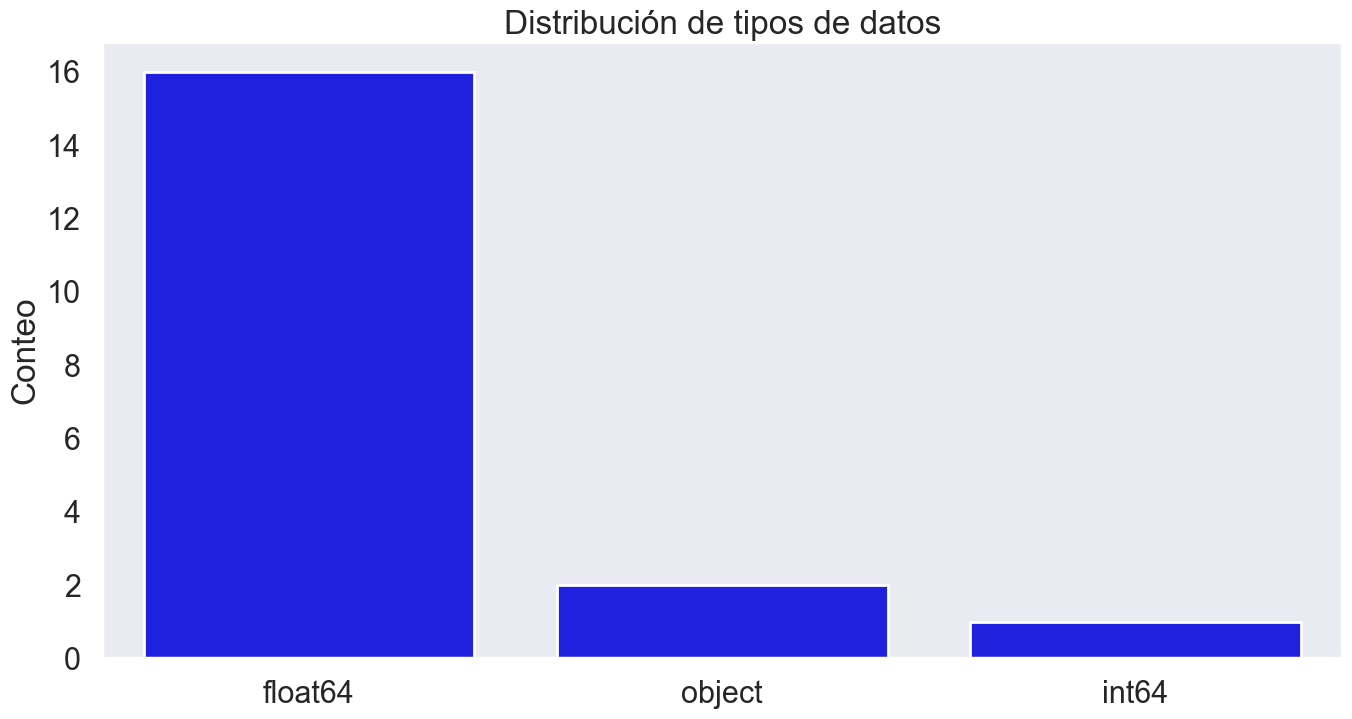

In [27]:
print("\nPaíses disponibles:")
print(df_cars_park['GEO (Labels)'].unique())

print("\nTipos de datos y resumen general:")
df_cars_park.info()

dtype_counts = df_cars_park.dtypes.value_counts().reset_index()
dtype_counts.columns = ['dtype', 'count']

plt.figure(figsize=(16, 8))
sns.barplot(data=dtype_counts, x='dtype', y='count', color='blue')
plt.title("Distribución de tipos de datos")
plt.ylabel("Conteo")
plt.xlabel(None)
plt.show()

#### Nulos por columna

Valores nulos por columna:
Plug-in hybrid petrol-electric      267
Plug-in hybrid diesel-electric      265
Biodiesel                           227
Bioethanol                          221
Bi-fuel                             201
Hybrid diesel-electric              174
Hybrid electric-petrol              155
Diesel (excluding hybrids)          122
Petrol (excluding hybrids)          110
Natural gas                         101
Liquefied petroleum gases (LPG)      95
Other                                94
Hydrogen and fuel cells              82
Alternative energy                   74
Electricity                          36
Total                                11
TIME                                  0
GEO (Codes)                           0
GEO (Labels)                          0
dtype: int64


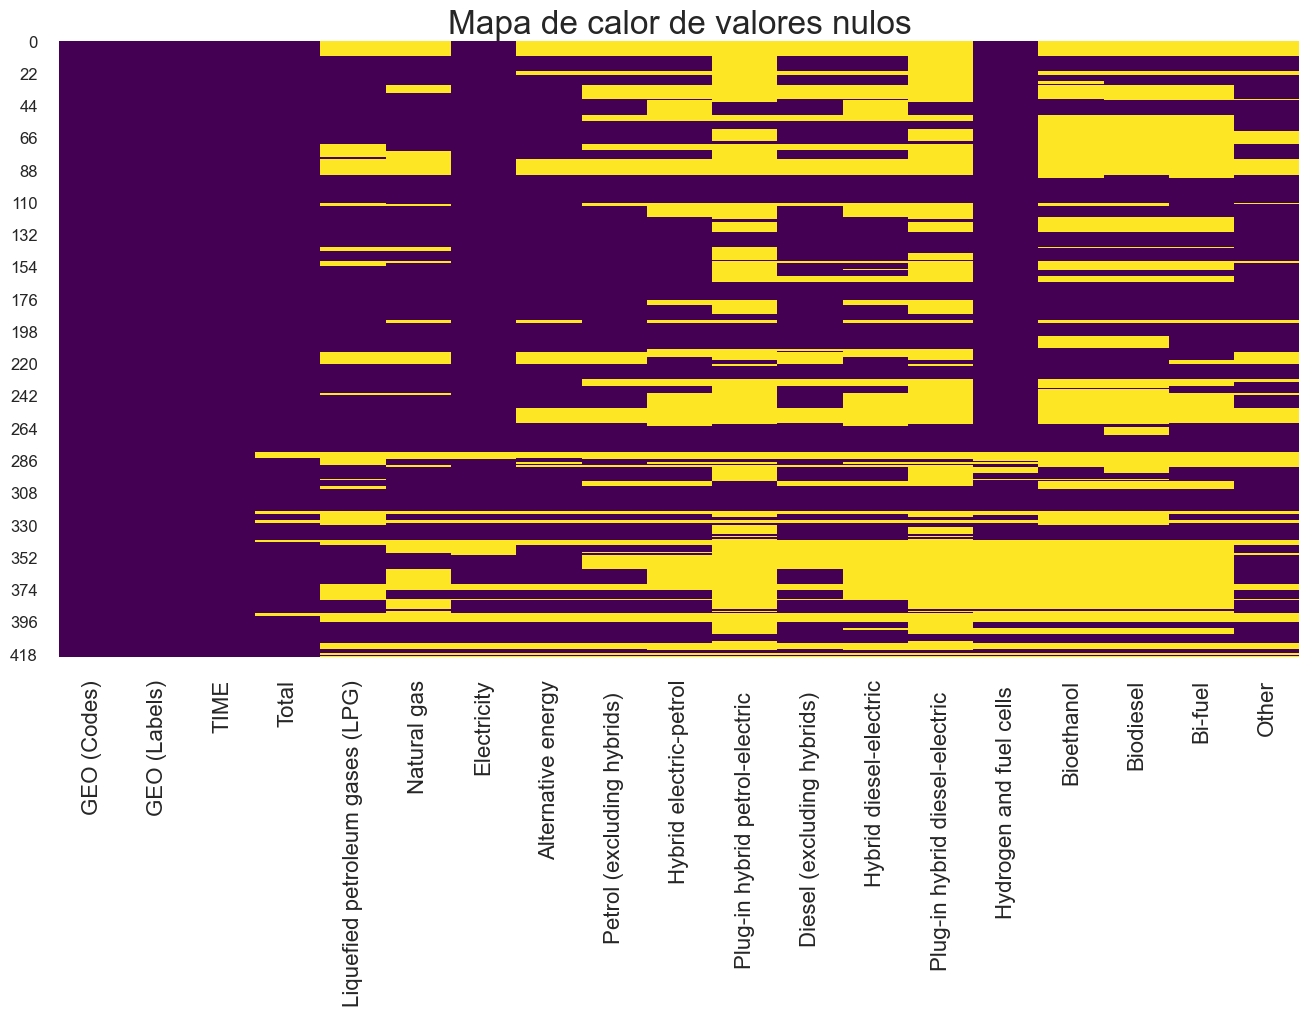

In [28]:
print("Valores nulos por columna:")
print(df_cars_park.isnull().sum().sort_values(ascending=False))

plt.figure(figsize=(16, 8))
sns.heatmap(df_cars_park.isnull(), cbar=False, cmap="viridis")
plt.title("Mapa de calor de valores nulos")
plt.xticks(fontsize=16)
plt.yticks(fontsize=12)
plt.show()

Valores nulos por columna:
Plug-in hybrid petrol-electric      173
Plug-in hybrid diesel-electric      169
Biodiesel                           142
Bioethanol                          140
Bi-fuel                             127
Hybrid diesel-electric              112
Hybrid electric-petrol              106
Diesel (excluding hybrids)           78
Petrol (excluding hybrids)           72
Other                                69
Liquefied petroleum gases (LPG)      56
Natural gas                          53
Alternative energy                   50
Hydrogen and fuel cells               7
Electricity                           5
Total                                 4
TIME                                  0
GEO (Codes)                           0
GEO (Labels)                          0
dtype: int64


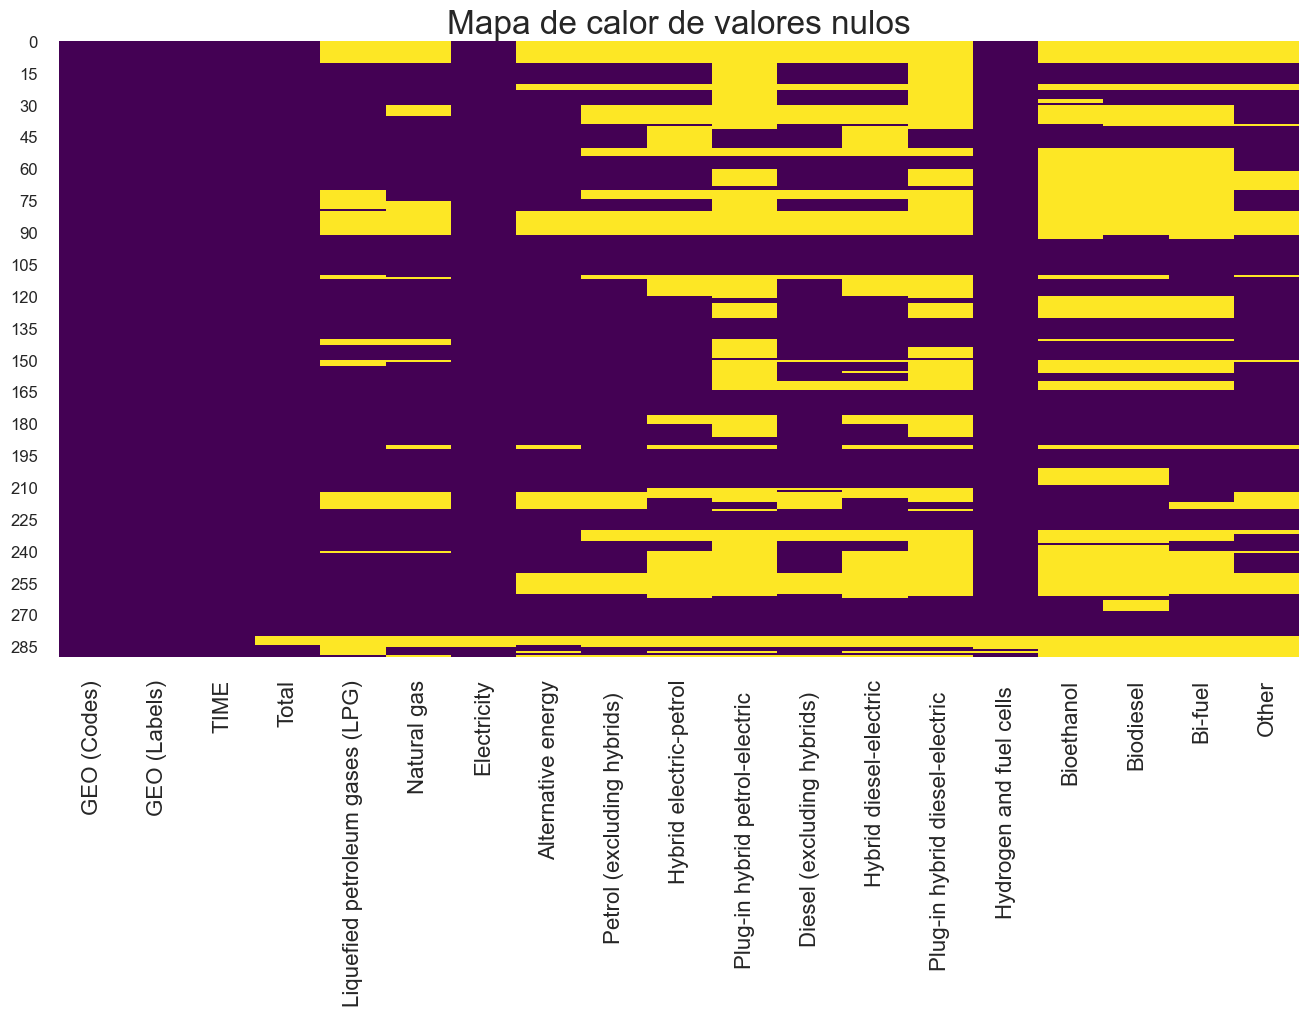

In [29]:
# Eliminar países que no forman parte de la Unión Europea (27)
df_cars_park_filtered = df_cars_park[~df_cars_park['GEO (Labels)'].isin([
    'Liechtenstein', 'Norway', 'Switzerland', 'United Kingdom',
    'Bosnia and Herzegovina', 'Montenegro', 'Moldova', 'North Macedonia',
    'Georgia', 'Albania', 'Serbia', 'Türkiye', 'Kosovo*'])]

print("Valores nulos por columna:")
print(df_cars_park_filtered.isnull().sum().sort_values(ascending=False))

plt.figure(figsize=(16, 8))
sns.heatmap(df_cars_park_filtered.isnull(), cbar=False, cmap="viridis")
plt.title("Mapa de calor de valores nulos")
plt.xticks(fontsize=16)
plt.yticks(fontsize=12)
plt.show()

#### Duplicados

In [30]:
print(f"Total de filas duplicadas: {df_cars_park.duplicated().sum()}")

Total de filas duplicadas: 0


#### Estadísticas descriptivas básicas

In [31]:
print("Estadísticas básicas (variables numéricas):")
print(df_cars_park.describe())

Estadísticas básicas (variables numéricas):
              TIME         Total  Liquefied petroleum gases (LPG)  \
count   420.000000  4.090000e+02                     3.250000e+02   
mean   2017.500000  1.267850e+07                     2.614180e+05   
std       2.875707  3.740714e+07                     8.997373e+05   
min    2013.000000  2.810000e+04                     0.000000e+00   
25%    2015.000000  7.078410e+05                     6.000000e+00   
50%    2017.500000  2.719396e+06                     5.900000e+01   
75%    2020.000000  5.778584e+06                     4.197900e+04   
max    2022.000000  2.526122e+08                     5.005530e+06   

         Natural gas   Electricity  Alternative energy  \
count     319.000000  3.840000e+02        3.460000e+02   
mean    33393.388715  4.973444e+04        3.528035e+05   
std    160343.727270  2.146653e+05        9.606304e+05   
min         0.000000  0.000000e+00        6.000000e+00   
25%        52.500000  3.030000e+02        8.

### 🔧 Transformaciones a realizar 🔧

En los siguientes bloques se realizarán tareas de limpieza, normalización y reestructuración del dataset para que esté listo para el análisis. Estas transformaciones tienen como propósito simplificar el dataset, facilitar el análisis comparativo por tipo de energía, y garantizar que los datos reflejen únicamente a la Unión Europea (27 países) de forma consolidada y comprensible.

1. __Filtrado geográfico__  
    Se eliminarán del dataset todos los países que no pertenecen a la Unión Europea (UE-27). Además, se removerá temporalmente la fila correspondiente al total de la UE (`European Union - 27 countries (from 2020)`) para poder recalcularla manualmente más adelante con datos actualizados.

2. __Renombrado y limpieza de columnas__  
    - Se limpiarán los nombres de columnas, eliminando espacios y caracteres problemáticos.
    - Se renombrarán columnas clave como "`Petrol_(excluding_hybrids)`" → "`Gasolina`" y "`Diesel_(excluding_hybrids)`" → "`Diesel`" para facilitar la lectura.
    - Se eliminarán columnas poco informativas o redundantes, como "`Total`" y "`Alternative energy`".  
    _Nota: la columna `Alternative energy`, presente en el dataset original, se encuentra vacía en múltiples filas, por lo que la descartaré. Además, no representa la suma directa de otras fuentes como gas natural o biocombustibles, por lo que se opta por construir una categoría propia más clara y útil para el análisis: `Gas_Bio_y_Bi`._

3. __Reagrupación de categorías energéticas__  
    - Se agruparán distintas columnas relacionadas con energías alternativas (LPG, gas natural, biocombustibles, bi-fuel) en una única columna llamada Gas_Bio_y_Bi.
    - De forma similar, se unifican las tecnologías eléctricas e híbridas en la nueva columna `Eléctricos`.

4. __Reconstrucción del total para la UE__  
    Luego del filtrado de países y la limpieza, se volverá a calcular el total de vehículos para la UE-27 sumando los valores por año.

#### Filtrado de países y limpieza básica

In [32]:
# Eliminar países que no forman parte de la Unión Europea (27)
df_cars_park = df_cars_park[~df_cars_park['GEO (Labels)'].isin([
    'Liechtenstein', 'Norway', 'Switzerland', 'United Kingdom',
    'Bosnia and Herzegovina', 'Montenegro', 'Moldova', 'North Macedonia',
    'Georgia', 'Albania', 'Serbia', 'Türkiye', 'Kosovo*'])]

# Limpiar nombres de columnas (quitar espacios y caracteres problemáticos)
df_cars_park.columns = df_cars_park.columns.str.strip().str.replace(' ', '_')

# Eliminar la fila de la UE-27 para recalcularla más adelante
df_cars_park = df_cars_park[~df_cars_park['GEO_(Labels)'].isin([
    'European Union - 27 countries (from 2020)'])]

# Agrupar los datos por año sumando valores de los países miembros
df_cars_park = df_cars_park.groupby('TIME').sum().reset_index()

# Reordenar columna TIME
df_cars_park.insert(2, 'TIME', df_cars_park.pop('TIME'))

# Actualizar los valores del código y etiqueta para representar a la UE-27
df_cars_park['GEO_(Codes)'] = df_cars_park['GEO_(Codes)'].replace(
    'BEBGCZDKDEEEIEELESFRHRITCYLVLTLUHUMTNLATPLPTROSISKFISEIS', 'EU27_2020')
df_cars_park['GEO_(Labels)'] = df_cars_park['GEO_(Labels)'].replace(
    'BelgiumBulgariaCzechiaDenmarkGermanyEstoniaIrelandGreeceSpainFranceCroatiaItalyCyprusLatviaLithuaniaLuxembourgHungaryMaltaNetherlandsAustriaPolandPortugalRomaniaSloveniaSlovakiaFinlandSwedenIceland',
    'European Union - 27 countries (from 2020)')

# Rellenar valores nulos consigo mismos (aparentemente redundante, pero evita errores)
df_cars_park = df_cars_park.fillna(df_cars_park)

#Columnas a excluir de la converción.
exclude_cols = ['GEO_(Codes)', 'GEO_(Labels)', 'TIME']

# Detectar columnas de tipo float (y que no estén en la lista de exclusión)
cols_to_convert = [
    col for col in df_cars_park.select_dtypes(include='float').columns
    if col not in exclude_cols
]
# Convertir a int (si estás seguro de que no hay NaN)
df_cars_park[cols_to_convert] = df_cars_park[cols_to_convert].astype(int)

# Mostrar dataframe
df_cars_park

,GEO_(Codes),GEO_(Labels),TIME,Total,Liquefied_petroleum_gases_(LPG),Natural_gas,Electricity,Alternative_energy,Petrol_(excluding_hybrids),Hybrid_electric-petrol,Plug-in_hybrid_petrol-electric,Diesel_(excluding_hybrids),Hybrid_diesel-electric,Plug-in_hybrid_diesel-electric,Hydrogen_and_fuel_cells,Bioethanol,Biodiesel,Bi-fuel,Other
0,EU27_2020,European Union - 27 countries (from 2020),2013,221705164,5704274,880229,50278,7658422,67795426,171332,30874,36683521,27910,1043,39,29326,2,317733,714507
1,EU27_2020,European Union - 27 countries (from 2020),2014,224317337,5851232,945716,76277,7782730,76912591,295448,36579,71752025,41249,1975,61,32771,62,311138,932856
2,EU27_2020,European Union - 27 countries (from 2020),2015,225651590,3016880,1000160,120093,4912311,66433065,503658,110698,68391653,75350,16843,222,35734,74,310903,627710
3,EU27_2020,European Union - 27 countries (from 2020),2016,230249119,3068760,1015628,168279,5322524,68636414,683205,144527,71210778,81955,20996,322,36890,73,385367,694920
4,EU27_2020,European Union - 27 countries (from 2020),2017,236305046,3144012,1032539,246099,5286744,100676997,1148380,221503,90375941,95120,24697,659,37257,67,374257,494892
5,EU27_2020,European Union - 27 countries (from 2020),2018,240677408,3328033,1074777,360033,5625418,106081702,1616154,297467,93818922,120635,25061,742,38098,198,404244,471622
6,EU27_2020,European Union - 27 countries (from 2020),2019,245120076,3485941,1115048,594142,6084796,108139562,2125577,389686,94010359,232440,34500,1004,49251,193,422227,471125
7,EU27_2020,European Union - 27 countries (from 2020),2020,247925660,3688787,1144046,1099721,6872636,108405255,2969572,757853,93592889,447978,63772,1498,57394,210,452196,491274
8,EU27_2020,European Union - 27 countries (from 2020),2021,250535896,3797021,1155015,1947205,7972374,108011923,4475432,1425244,92399916,789763,105395,2153,77297,216,524471,533211
9,EU27_2020,European Union - 27 countries (from 2020),2022,252899596,3947995,1143058,3026755,9361894,110968329,6145843,2043454,93169033,1090099,131514,3213,169414,186,594066,580317


#### Renombrado y eliminación de columnas

In [33]:
# Eliminar columnas no informativas o redundantes
df_cars_park = df_cars_park.drop(['GEO_(Labels)', 'Total', 'Alternative_energy'], axis=1)

# Renombrar columnas clave para mejorar la legibilidad
df_cars_park = df_cars_park.rename(columns={
    'GEO_(Codes)':'Geocodificación', 'TIME':'Años',
    'Petrol_(excluding_hybrids)': 'Gasolina',
    'Diesel_(excluding_hybrids)': 'Diesel',
    'Other': 'Otros'})

#### Reagrupación de categorías energéticas

In [34]:
# Crear nueva columna agrupada con energías alternativas (gas, bio y bi-fuel)
df_cars_park['Gas_Bio_y_Bi'] = df_cars_park[[
    'Liquefied_petroleum_gases_(LPG)', 'Natural_gas',
    'Bioethanol', 'Biodiesel', 'Bi-fuel']].sum(axis=1)

# Eliminar las columnas originales ya agrupadas
df_cars_park = df_cars_park.drop([
    'Liquefied_petroleum_gases_(LPG)', 'Natural_gas',
    'Bioethanol', 'Biodiesel', 'Bi-fuel'], axis=1)

# Reubicar la nueva columna
df_cars_park.insert(2, 'Gas_Bio_y_Bi', df_cars_park.pop('Gas_Bio_y_Bi'))

# Crear columna agrupada de tecnologías eléctricas e híbridas
df_cars_park['Eléctricos'] = df_cars_park[[
    'Electricity', 'Hydrogen_and_fuel_cells', 'Hybrid_electric-petrol',
    'Hybrid_diesel-electric', 'Plug-in_hybrid_petrol-electric',
    'Plug-in_hybrid_diesel-electric']].sum(axis=1)

# Eliminar las columnas originales ya agrupadas
df_cars_park = df_cars_park.drop([
    'Electricity', 'Hydrogen_and_fuel_cells', 'Hybrid_electric-petrol',
    'Hybrid_diesel-electric', 'Plug-in_hybrid_petrol-electric',
    'Plug-in_hybrid_diesel-electric'], axis=1)

# Reubicar la nueva columna
df_cars_park.insert(3, 'Eléctricos', df_cars_park.pop('Eléctricos'))

# Mostrar resultado final
df_cars_park

,Geocodificación,Años,Gas_Bio_y_Bi,Eléctricos,Gasolina,Diesel,Otros
0,EU27_2020,2013,6931564,281476,67795426,36683521,714507
1,EU27_2020,2014,7140919,451589,76912591,71752025,932856
2,EU27_2020,2015,4363751,826864,66433065,68391653,627710
3,EU27_2020,2016,4506718,1099284,68636414,71210778,694920
4,EU27_2020,2017,4588132,1736458,100676997,90375941,494892
5,EU27_2020,2018,4845350,2420092,106081702,93818922,471622
6,EU27_2020,2019,5072660,3377349,108139562,94010359,471125
7,EU27_2020,2020,5342633,5340394,108405255,93592889,491274
8,EU27_2020,2021,5554020,8745192,108011923,92399916,533211
9,EU27_2020,2022,5854719,12440878,110968329,93169033,580317


#### 💾 Exportación del dataset limpio 💾

El DataFrame transformado se guarda como archivo `.csv` en la carpeta `Datasets_procesados`. Esto permite reutilizar los datos ya procesados sin volver a ejecutar todos los pasos anteriores.

In [35]:
# Crear la ruta de exportación
output_dir = os.path.join(os.getcwd(), "Datasets_procesados")
os.makedirs(output_dir, exist_ok=True)  # Para crear la carpeta si no existe

# Ruta final del archivo
output_path = os.path.join(output_dir, "df_cars_park.csv")

# Guardar el archivo
df_greenhouse_gases.to_csv(output_path, index=False, encoding='utf-8')

### Visualizaciones exploratorias.

#### Evolución del parque motor en Europa

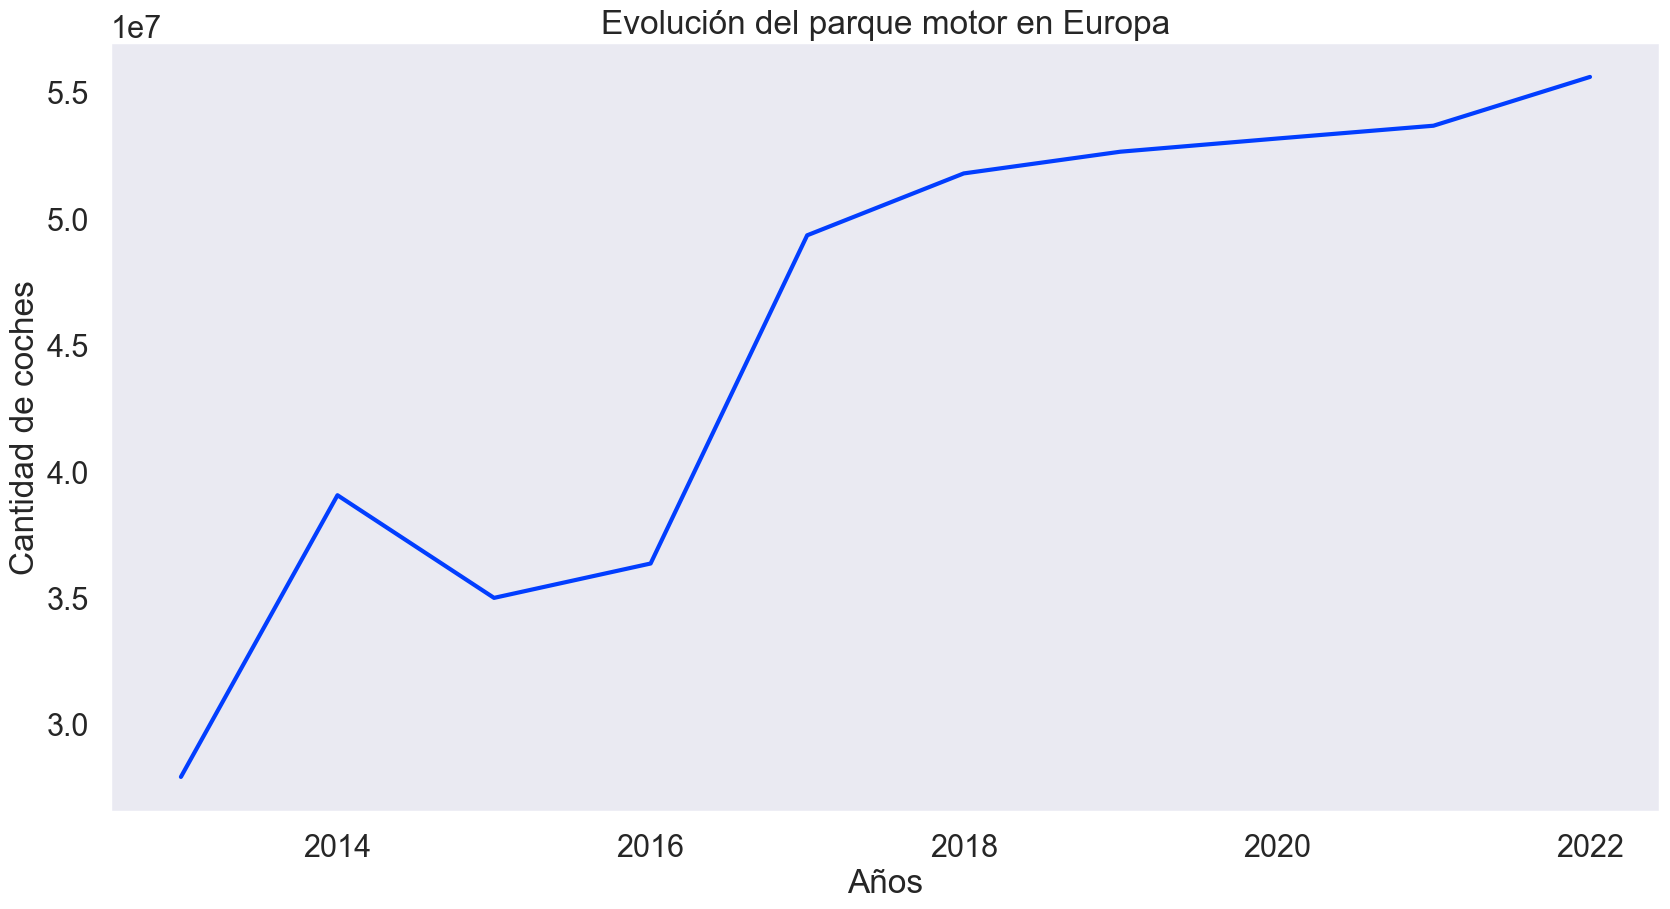

In [36]:
id_vars = 'Años'
value_vars = ['Gas_Bio_y_Bi', 'Eléctricos', 'Gasolina', 'Diesel']

df_long = df_cars_park.melt(id_vars=id_vars, value_vars=value_vars, var_name='Motor', value_name='Cantidad de coches')

plt.figure(figsize=(20, 10))
sns.lineplot(data=df_long, x='Años', y='Cantidad de coches', errorbar=None)
plt.title('Evolución del parque motor en Europa')
plt.show()

#### Evolución de la cantidad de coches en mercado por tipos de motor

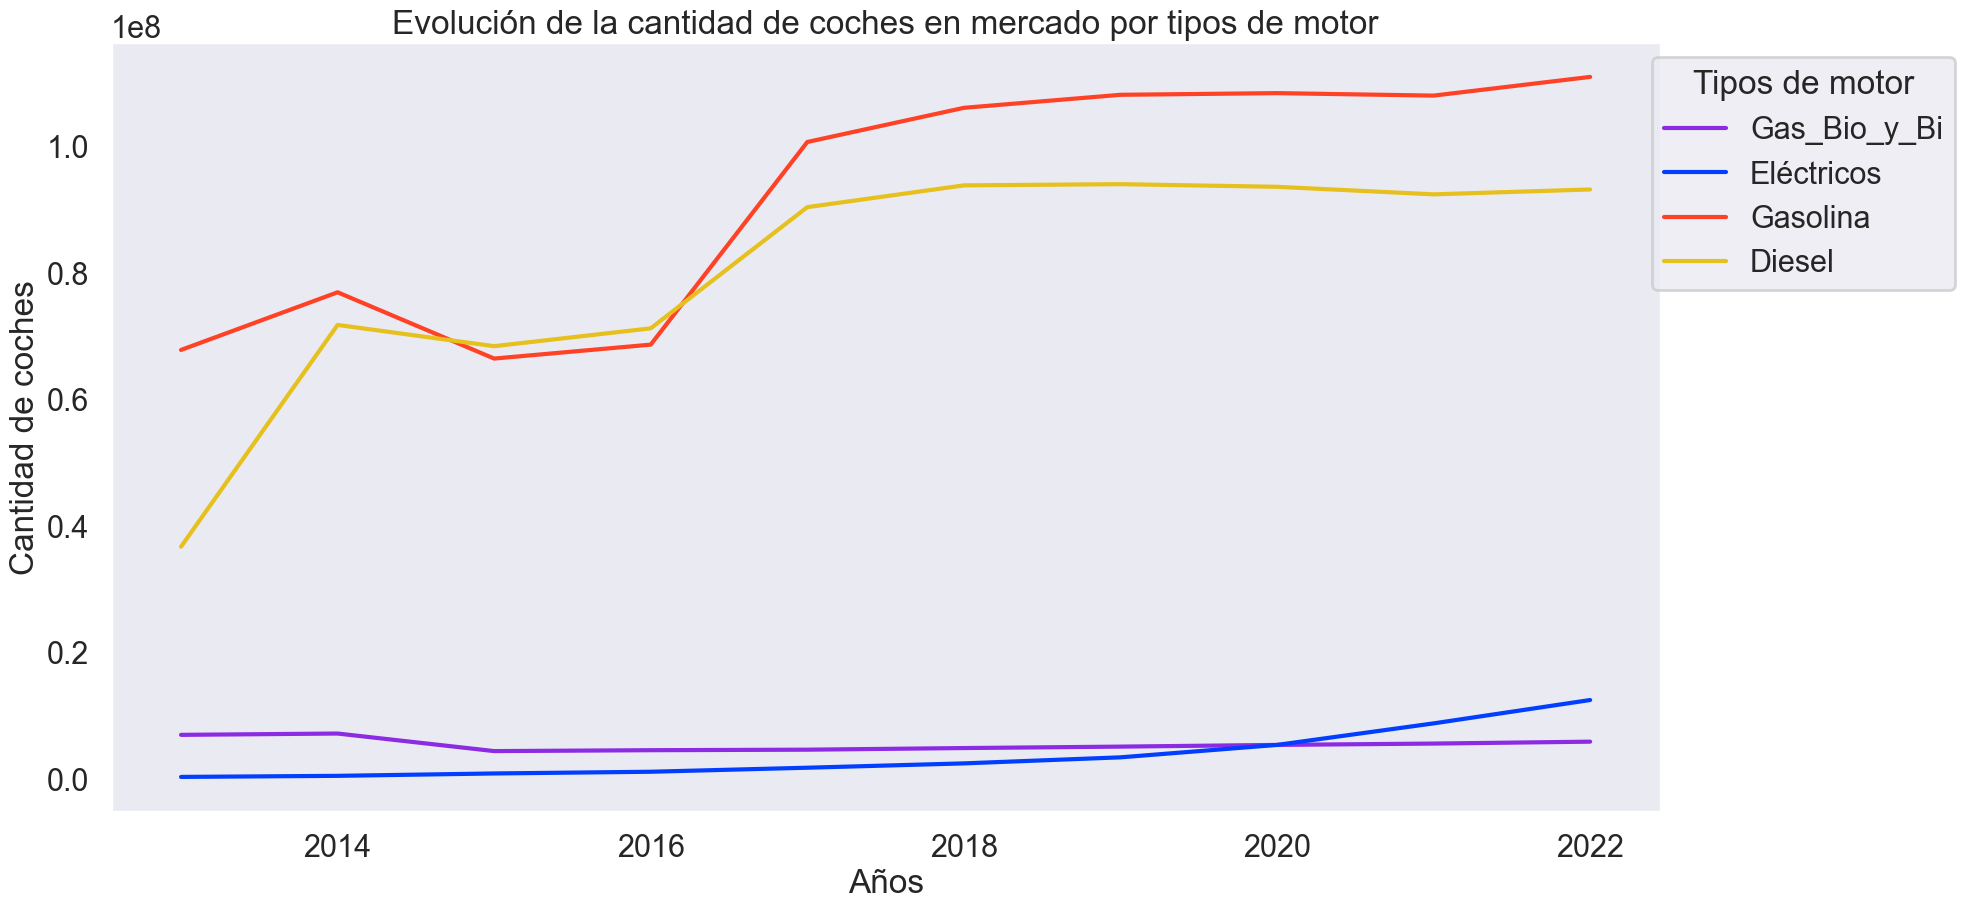

In [37]:
id_vars = 'Años'
value_vars = ['Gas_Bio_y_Bi', 'Eléctricos', 'Gasolina', 'Diesel']
custom_palette = {'Gas_Bio_y_Bi': '#8b2be2', 'Eléctricos': '#023eff', 'Gasolina': '#ff4126', 'Diesel': '#e6c01c'}

df_long = df_cars_park.melt(id_vars=id_vars, value_vars=value_vars, var_name='Motor', value_name='Cantidad de coches')

plt.figure(figsize=(20, 10))
sns.lineplot(data=df_long, x='Años', y='Cantidad de coches', hue='Motor', palette=custom_palette)
plt.legend(title='Tipos de motor', loc='upper right', bbox_to_anchor=(1.2, 1))
plt.title('Evolución de la cantidad de coches en mercado por tipos de motor')
plt.show()

#### Comparativa de la cantidad de coches entre los años 2013 y 2022

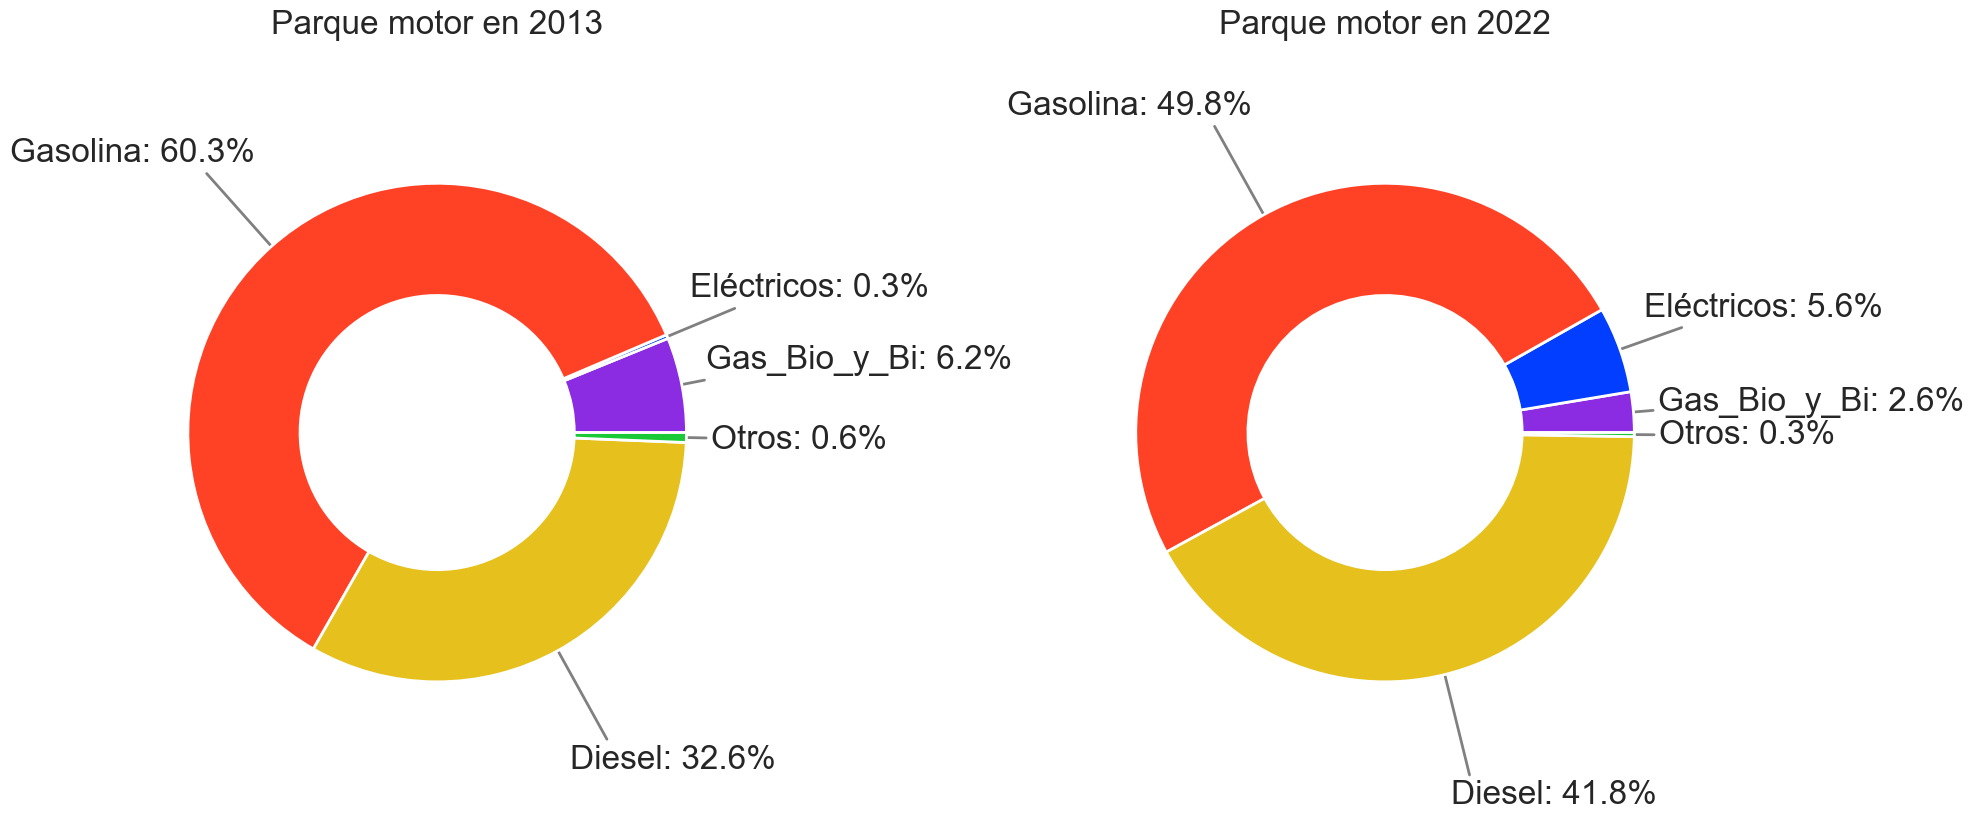

In [38]:
df_2013 = df_cars_park[df_cars_park['Años'] == 2013]
df_2022 = df_cars_park[df_cars_park['Años'] == 2022]
columns = ['Gas_Bio_y_Bi', 'Eléctricos', 'Gasolina', 'Diesel', 'Otros']

data_2013 = df_2013[columns].sum()
data_2022 = df_2022[columns].sum()

colors_dict = {'Gas_Bio_y_Bi': '#8b2be2', 'Eléctricos': '#023eff',
               'Gasolina': '#ff4126', 'Diesel': '#e6c01c', 'Otros': '#1ac938'}

def plot_donut(ax, data, title):
    labels = data.index
    values = data.values
    total = sum(values)
    percentages = [v / total * 100 for v in values]
    colors = [colors_dict[l] for l in labels]

    wedges, _ = ax.pie(values, wedgeprops=dict(width=0.45), colors=colors)

    kw = dict(
        arrowprops=dict(arrowstyle="-", shrinkA=1, shrinkB=0, lw=2, color="gray"),
        zorder=0, va="center")

    for i, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1) / 2. + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
        connectionstyle = f"angle,angleA=0,angleB={ang}"
        kw["arrowprops"].update({"connectionstyle": connectionstyle})
        label = f"{labels[i]}: {percentages[i]:.1f}%"
        ax.annotate(label, xy=(x, y), xytext=(1.1*x, 1.5*y),
                    horizontalalignment=horizontalalignment, **kw)

    ax.set_title(title)
    ax.axis('equal')

fig, axs = plt.subplots(1, 2, figsize=(20, 10))
plot_donut(axs[0], data_2013, "Parque motor en 2013")
plot_donut(axs[1], data_2022, "Parque motor en 2022")
plt.tight_layout()
plt.show()

___
## 🚗 __Nuevos automóviles, por tipo de energía motriz__ 🚗

### 📊 Dataset utilizado 📊
__Nombre__: _New passenger cars by type of motor energy_ (`road_eqr_carpda`)  
__Fuente oficial__: [Eurostat)](https://ec.europa.eu/eurostat)  
__Acceso a los datos__: [Eurostat - Data Browser](https://ec.europa.eu/eurostat/databrowser/view/road_eqr_carpda__custom_17309631/default/table?lang=en)

#### Descripción general del dataset

Este conjunto de datos proporciona información sobre el número de automóviles de pasajeros nuevos registrados en cada país de la Unión Europea, clasificados según el tipo de energía del motor. Es útil para analizar las tendencias recientes en la adopción de tecnologías de propulsión más sostenibles, así como para evaluar el ritmo de transición energética en el sector del transporte.

- Frecuencia temporal: Anual (A)
- Unidad de medida: Miles de toneladas (THS_T)
- Cobertura geográfica: Países de la Unión Europea
- Tipos de motor:
    - Gasolina
    - Diésel
    - Vehículos eléctricos de batería (BEV)
    - Híbridos (enchufables y no enchufables de gasolina o diésel)
    - Gas natural, GLP, y biocombustibles.

#### Notas adicionales

Este dataset complementa al de vehículos en circulación (road_eqs_carpda), permitiendo comparar:
- El parque automotor total vs. la entrada de vehículos nuevos.
- La evolución del mercado hacia fuentes de energía menos contaminantes.
- El impacto potencial futuro en emisiones según el tipo de motorización que predomina en los nuevos registros.

### 🧭 Carga de datos 🧭

En este paso se carga el archivo Excel que contiene los datos de emisiones de gases de efecto invernadero. El archivo debe estar ubicado en la carpeta `Datasets_crudos`, dentro del directorio principal del proyecto.

In [39]:
file_path = os.path.join(os.getcwd(), "Datasets_crudos", "road_eqr_carpda__custom_15714427_page_spreadsheet.xlsx")

with open(file_path, "rb") as data:
    df_new_cars = pd.read_excel(data, sheet_name="Data")
df_new_cars.head(10)

,GEO (Codes),GEO (Labels),TIME,Liquefied petroleum gases (LPG),Natural gas,Electricity,Alternative energy,Petrol (excluding hybrids),Hybrid electric-petrol,Plug-in hybrid petrol-electric,Diesel (excluding hybrids),Hybrid diesel-electric,Plug-in hybrid diesel-electric,Hydrogen and fuel cells,Bioethanol,Biodiesel,Bi-fuel,Other
0,EU27_2020,European Union - 27 countries (from 2020),2013,NaN,NaN,21908.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN
1,EU27_2020,European Union - 27 countries (from 2020),2014,NaN,NaN,30892.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.0,NaN,NaN,NaN,NaN
2,EU27_2020,European Union - 27 countries (from 2020),2015,NaN,NaN,46641.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126.0,NaN,NaN,NaN,NaN
3,EU27_2020,European Union - 27 countries (from 2020),2016,NaN,NaN,53544.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,104.0,NaN,NaN,NaN,NaN
4,EU27_2020,European Union - 27 countries (from 2020),2017,NaN,NaN,83778.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,214.0,NaN,NaN,NaN,NaN
5,EU27_2020,European Union - 27 countries (from 2020),2018,NaN,NaN,134506.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,223.0,NaN,NaN,NaN,NaN
6,EU27_2020,European Union - 27 countries (from 2020),2019,NaN,NaN,250082.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,480.0,NaN,NaN,NaN,NaN
7,EU27_2020,European Union - 27 countries (from 2020),2020,NaN,NaN,539028.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,751.0,NaN,NaN,NaN,NaN
8,EU27_2020,European Union - 27 countries (from 2020),2021,NaN,NaN,885298.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,866.0,NaN,NaN,NaN,NaN
9,EU27_2020,European Union - 27 countries (from 2020),2022,NaN,NaN,1129786.0,1399095.0,3373144.0,1849058.0,NaN,1537136.0,NaN,NaN,1206.0,NaN,NaN,NaN,NaN


### 🔎 Análisis exploratorio de datos (EDA) 🔍

En esta sección se realiza una inspección inicial del dataset crudo, para comprender su estructura, calidad y contenido antes de aplicar transformaciones.

Comprobaré:
- Tipos de datos
- Presencia de valores nulos.
- Duplicados.
- Estadísticas descriptivas básicas.


#### Información general del DataFrame


Países disponibles:
['European Union - 27 countries (from 2020)' 'Belgium' 'Bulgaria'
 'Czechia' 'Denmark' 'Germany' 'Estonia' 'Ireland' 'Greece' 'Spain'
 'France' 'Croatia' 'Italy' 'Cyprus' 'Latvia' 'Lithuania' 'Luxembourg'
 'Hungary' 'Malta' 'Netherlands' 'Austria' 'Poland' 'Portugal' 'Romania'
 'Slovenia' 'Slovakia' 'Finland' 'Sweden' 'Iceland' 'Liechtenstein'
 'Norway' 'Switzerland' 'United Kingdom' 'Bosnia and Herzegovina'
 'Montenegro' 'Moldova' 'Georgia' 'Albania' 'Serbia' 'Türkiye' 'Ukraine'
 'Kosovo*']

Tipos de datos y resumen general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   GEO (Codes)                       420 non-null    object 
 1   GEO (Labels)                      420 non-null    object 
 2   TIME                              420 non-null    int64  
 3   Liquefied petroleum ga

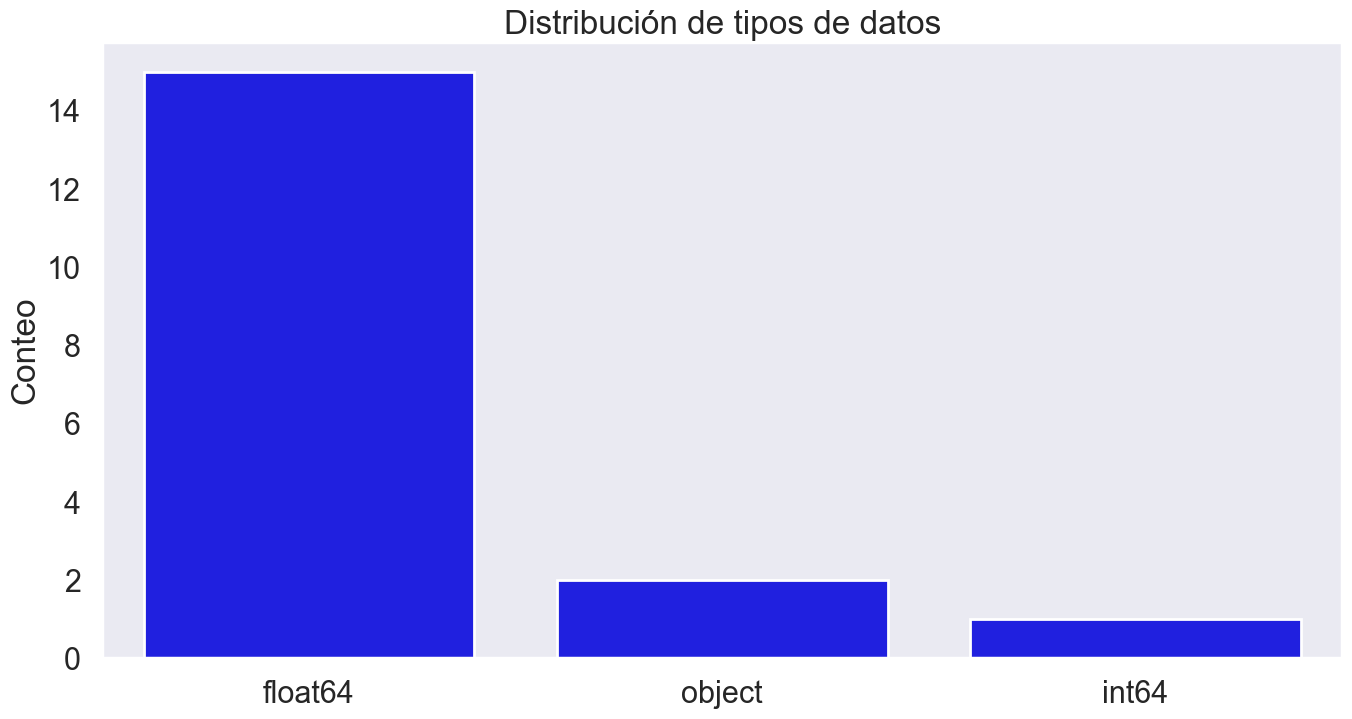

In [40]:
print("\nPaíses disponibles:")
print(df_new_cars['GEO (Labels)'].unique())

print("\nTipos de datos y resumen general:")
df_new_cars.info()

dtype_counts = df_new_cars.dtypes.value_counts().reset_index()
dtype_counts.columns = ['dtype', 'count']

plt.figure(figsize=(16, 8))
sns.barplot(data=dtype_counts, x='dtype', y='count', color='blue')
plt.title("Distribución de tipos de datos")
plt.ylabel("Conteo")
plt.xlabel(None)
plt.show()

#### Nulos por columna

Valores nulos por columna:
Plug-in hybrid diesel-electric      275
Plug-in hybrid petrol-electric      268
Biodiesel                           255
Bioethanol                          242
Bi-fuel                             206
Hybrid diesel-electric              204
Other                               162
Hybrid electric-petrol              152
Liquefied petroleum gases (LPG)     146
Natural gas                         140
Diesel (excluding hybrids)          134
Petrol (excluding hybrids)          132
Alternative energy                   96
Hydrogen and fuel cells              75
Electricity                          44
GEO (Codes)                           0
GEO (Labels)                          0
TIME                                  0
dtype: int64


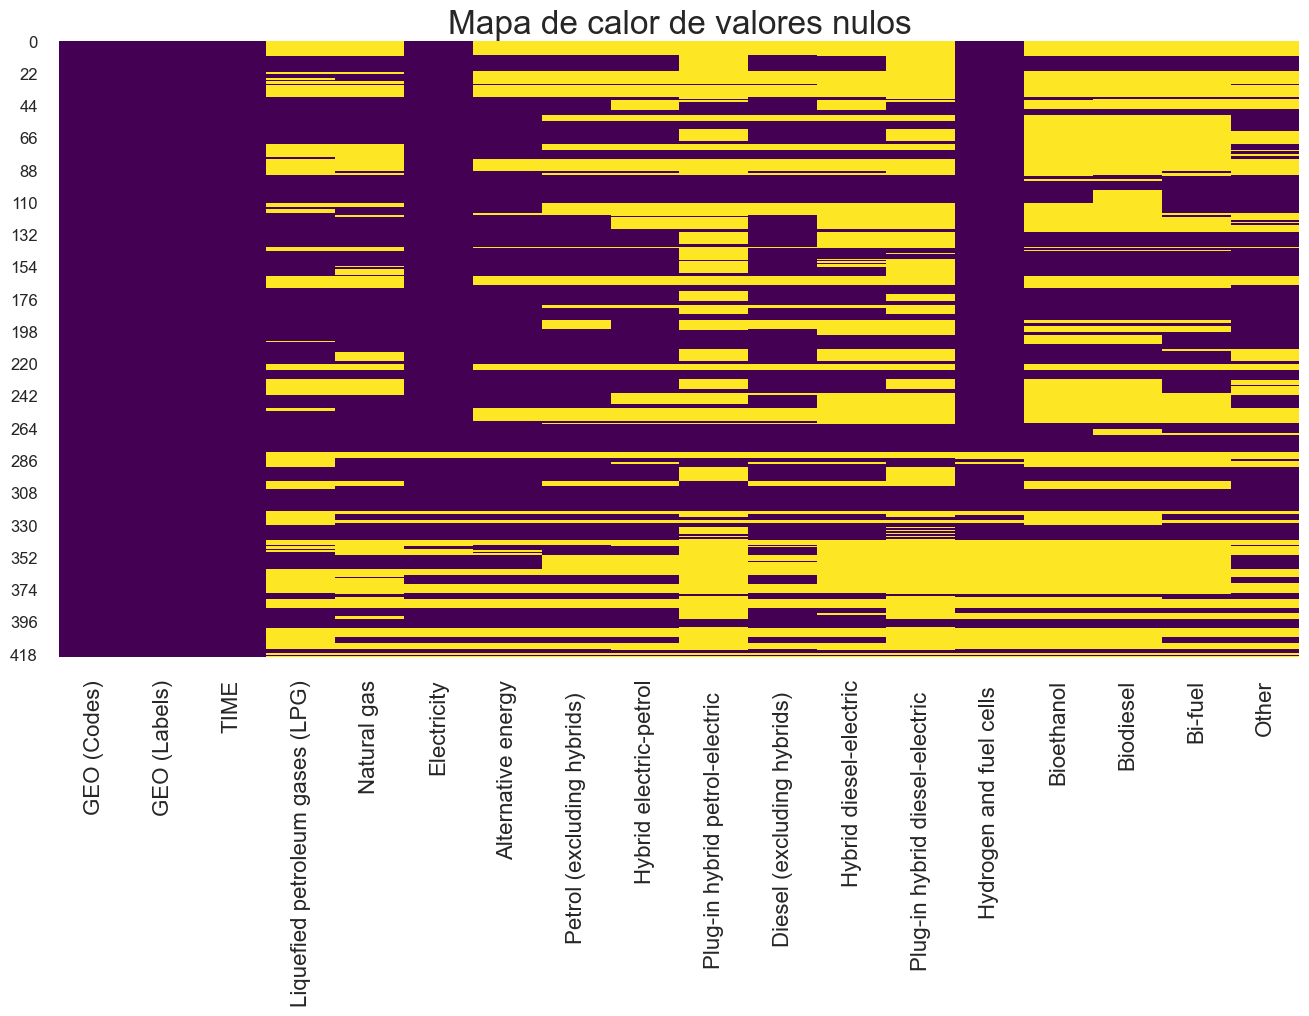

In [41]:
print("Valores nulos por columna:")
print(df_new_cars.isnull().sum().sort_values(ascending=False))

plt.figure(figsize=(16, 8))
sns.heatmap(df_new_cars.isnull(), cbar=False, cmap="viridis")
plt.title("Mapa de calor de valores nulos")
plt.xticks(fontsize=16)
plt.yticks(fontsize=12)
plt.show()

#### Duplicados

In [42]:
print(f"Total de filas duplicadas: {df_new_cars.duplicated().sum()}")

Total de filas duplicadas: 0


#### Estadísticas descriptivas básicas

In [43]:
print("Estadísticas básicas (variables numéricas):")
print(df_new_cars.describe())

Estadísticas básicas (variables numéricas):
              TIME  Liquefied petroleum gases (LPG)   Natural gas  \
count   420.000000                       274.000000    280.000000   
mean   2017.500000                      5793.919708   2025.735714   
std       2.875707                     22395.164070   8730.614326   
min    2013.000000                         0.000000      0.000000   
25%    2015.000000                         0.000000      2.000000   
50%    2017.500000                         1.000000     33.000000   
75%    2020.000000                       560.000000    429.750000   
max    2022.000000                    137096.000000  72387.000000   

        Electricity  Alternative energy  Petrol (excluding hybrids)    \
count  3.760000e+02        3.240000e+02                  2.880000e+02   
mean   2.016215e+04        2.629051e+04                  1.958268e+05   
std    8.916610e+04        9.392862e+04                  3.860023e+05   
min    0.000000e+00        0.000000e+00   

### 🔧 Transformaciones a realizar 🔧

En los siguientes bloques se realizarán tareas de limpieza, normalización y reestructuración del dataset para que esté listo para el análisis. Estas transformaciones tienen como propósito simplificar el dataset, facilitar el análisis comparativo por tipo de energía, y garantizar que los datos reflejen únicamente a la Unión Europea (27 países) de forma consolidada y comprensible.

1. __Filtrado geográfico__  
    Se eliminarán del dataset todos los países que no pertenecen a la Unión Europea (UE-27). Además, se removerá temporalmente la fila correspondiente al total de la UE (`European Union - 27 countries (from 2020)`) para poder recalcularla manualmente más adelante con datos actualizados.

2. __Renombrado y limpieza de columnas__  
    - Se limpiarán los nombres de columnas, eliminando espacios y caracteres problemáticos.
    - Se renombrarán columnas clave como "`Petrol_(excluding_hybrids)`" → "`Gasolina`" y "`Diesel_(excluding_hybrids)`" → "`Diesel`" para facilitar la lectura.
    - Se eliminará la columna "`Alternative energy`" por ser poco informativas o redundantes.  
    _Nota: la columna `Alternative energy`, presente en el dataset original, se encuentra vacía en múltiples filas, por lo que la descartaré. Además, no representa la suma directa de otras fuentes como gas natural o biocombustibles, por lo que se opta por construir una categoría propia más clara y útil para el análisis: `Gas_Bio_y_Bi`._

3. __Reagrupación de categorías energéticas__  
    - Se agruparán distintas columnas relacionadas con energías alternativas (LPG, gas natural, biocombustibles, bi-fuel) en una única columna llamada Gas_Bio_y_Bi.
    - De forma similar, se unifican las tecnologías eléctricas e híbridas en la nueva columna `Eléctricos`.

4. __Reconstrucción del total para la UE__  
    Luego del filtrado de países y la limpieza, se volverá a calcular el total de vehículos para la UE-27 sumando los valores por año.

#### Filtrado de países y limpieza básica

In [44]:
# Eliminar países que no forman parte de la Unión Europea (27)
df_new_cars = df_new_cars[~df_new_cars['GEO (Labels)'].isin([
    'Liechtenstein', 'Norway', 'Switzerland', 'United Kingdom',
    'Bosnia and Herzegovina', 'Montenegro', 'Moldova', 'North Macedonia',
    'Georgia', 'Albania', 'Serbia', 'Türkiye', 'Ukraine', 'Kosovo*'])]

# Limpiar nombres de columnas (quitar espacios y caracteres problemáticos)
df_new_cars.columns = df_new_cars.columns.str.strip().str.replace(' ', '_')

# Eliminar la fila de la UE-27 para recalcularla más adelante
df_new_cars = df_new_cars[~df_new_cars['GEO_(Labels)'].isin([
    'European Union - 27 countries (from 2020)'])]

# Agrupar los datos por año sumando valores de los países miembros
df_new_cars = df_new_cars.groupby('TIME').sum().reset_index()

# Reordenar columna TIME
df_new_cars.insert(2, 'TIME', df_new_cars.pop('TIME'))

# Actualizar los valores del código y etiqueta para representar a la UE-27
df_new_cars['GEO_(Codes)'] = df_new_cars['GEO_(Codes)'].replace(
    'BEBGCZDKDEEEIEELESFRHRITCYLVLTLUHUMTNLATPLPTROSISKFISEIS', 'EU27_2020')
df_new_cars['GEO_(Labels)'] = df_new_cars['GEO_(Labels)'].replace(
    'BelgiumBulgariaCzechiaDenmarkGermanyEstoniaIrelandGreeceSpainFranceCroatiaItalyCyprusLatviaLithuaniaLuxembourgHungaryMaltaNetherlandsAustriaPolandPortugalRomaniaSloveniaSlovakiaFinlandSwedenIceland',
    'European Union - 27 countries (from 2020)')

# Rellenar valores nulos consigo mismos (aparentemente redundante, pero evita errores)
df_new_cars = df_new_cars.fillna(df_new_cars)

#Columnas a excluir de la converción.
exclude_cols = ['GEO_(Codes)', 'GEO_(Labels)', 'TIME']

# Detectar columnas de tipo float (y que no estén en la lista de exclusión)
cols_to_convert = [
    col for col in df_new_cars.select_dtypes(include='float').columns
    if col not in exclude_cols
]
# Convertir a int (si estás seguro de que no hay NaN)
df_new_cars[cols_to_convert] = df_new_cars[cols_to_convert].astype(int)

# Mostrar dataframe
df_new_cars

,GEO_(Codes),GEO_(Labels),TIME,Liquefied_petroleum_gases_(LPG),Natural_gas,Electricity,Alternative_energy,Petrol_(excluding_hybrids),Hybrid_electric-petrol,Plug-in_hybrid_petrol-electric,Diesel_(excluding_hybrids),Hybrid_diesel-electric,Plug-in_hybrid_diesel-electric,Hydrogen_and_fuel_cells,Bioethanol,Biodiesel,Bi-fuel,Other
0,EU27_2020,European Union - 27 countries (from 2020),2013,127712,79897,21908,266653,1759604,90269,1274,2783435,15233,861,7,670,2,6617,30476
1,EU27_2020,European Union - 27 countries (from 2020),2014,137463,86343,30892,295899,2176478,90201,5422,3477677,10645,1073,21,604,6,8537,32428
2,EU27_2020,European Union - 27 countries (from 2020),2015,133943,70743,46641,296713,2618876,128297,12554,3664274,22120,863,126,347,1,8536,38006
3,EU27_2020,European Union - 27 countries (from 2020),2016,113317,49513,53544,279173,3175756,158323,19094,3882988,6174,1845,104,1086,0,10377,53711
4,EU27_2020,European Union - 27 countries (from 2020),2017,147922,39971,84623,290078,5765771,292871,64868,5435460,3911,3105,214,12,0,15250,6652
5,EU27_2020,European Union - 27 countries (from 2020),2018,142841,52018,135290,371080,6584154,388438,85220,4590472,24931,2596,239,28,27,36818,6622
6,EU27_2020,European Union - 27 countries (from 2020),2019,158148,63787,251172,507394,7265619,517252,105767,4075878,111447,10909,487,59,21,30124,7526
7,EU27_2020,European Union - 27 countries (from 2020),2020,115548,53264,541579,745007,4557309,807889,408448,2761380,201908,33208,751,26,35,38429,2088
8,EU27_2020,European Union - 27 countries (from 2020),2021,139164,43060,889544,1160662,3869164,1609253,757933,1939659,404595,56313,869,21,0,86265,4258
9,EU27_2020,European Union - 27 countries (from 2020),2022,160251,18113,1135353,1404666,3375129,1851460,772737,1539521,388708,45446,1206,32,2,83880,5829


#### Renombrado y eliminación de columnas

In [45]:
# Eliminar columnas no informativas o redundantes
df_new_cars = df_new_cars.drop(['GEO_(Labels)', 'Alternative_energy'], axis=1)

# Renombrar columnas clave para mejorar la legibilidad
df_new_cars = df_new_cars.rename(columns={
    'GEO_(Codes)':'Geocodificación', 'TIME':'Años',
    'Petrol_(excluding_hybrids)': 'Gasolina',
    'Diesel_(excluding_hybrids)': 'Diesel',
    'Other': 'Otros'})

#### Reagrupación de categorías energéticas

In [46]:
# Crear nueva columna agrupada con energías alternativas (gas, bio y bi-fuel)
df_new_cars['Gas_Bio_y_Bi'] = df_new_cars[[
    'Liquefied_petroleum_gases_(LPG)', 'Natural_gas',
    'Bioethanol', 'Biodiesel', 'Bi-fuel']].sum(axis=1)

# Eliminar las columnas originales ya agrupadas
df_new_cars = df_new_cars.drop([
    'Liquefied_petroleum_gases_(LPG)', 'Natural_gas',
    'Bioethanol', 'Biodiesel', 'Bi-fuel'], axis=1)

# Reubicar la nueva columna
df_new_cars.insert(2, 'Gas_Bio_y_Bi', df_new_cars.pop('Gas_Bio_y_Bi'))

# Crear columna agrupada de tecnologías eléctricas e híbridas
df_new_cars['Eléctricos'] = df_new_cars[[
    'Electricity', 'Hydrogen_and_fuel_cells', 'Hybrid_electric-petrol',
    'Hybrid_diesel-electric', 'Plug-in_hybrid_petrol-electric',
    'Plug-in_hybrid_diesel-electric']].sum(axis=1)

# Eliminar las columnas originales ya agrupadas
df_new_cars = df_new_cars.drop([
    'Electricity', 'Hydrogen_and_fuel_cells', 'Hybrid_electric-petrol',
    'Hybrid_diesel-electric', 'Plug-in_hybrid_petrol-electric',
    'Plug-in_hybrid_diesel-electric'], axis=1)

# Reubicar la nueva columna
df_new_cars.insert(3, 'Eléctricos', df_new_cars.pop('Eléctricos'))

# Mostrar resultado final
df_new_cars

,Geocodificación,Años,Gas_Bio_y_Bi,Eléctricos,Gasolina,Diesel,Otros
0,EU27_2020,2013,214898,129552,1759604,2783435,30476
1,EU27_2020,2014,232953,138254,2176478,3477677,32428
2,EU27_2020,2015,213570,210601,2618876,3664274,38006
3,EU27_2020,2016,174293,239084,3175756,3882988,53711
4,EU27_2020,2017,203155,449592,5765771,5435460,6652
5,EU27_2020,2018,231732,636714,6584154,4590472,6622
6,EU27_2020,2019,252139,997034,7265619,4075878,7526
7,EU27_2020,2020,207302,1993783,4557309,2761380,2088
8,EU27_2020,2021,268510,3718507,3869164,1939659,4258
9,EU27_2020,2022,262278,4194910,3375129,1539521,5829


#### 💾 Exportación del dataset limpio 💾

El DataFrame transformado se guarda como archivo `.csv` en la carpeta `Datasets_procesados`. Esto permite reutilizar los datos ya procesados sin volver a ejecutar todos los pasos anteriores.

In [47]:
# Crear la ruta de exportación
output_dir = os.path.join(os.getcwd(), "Datasets_procesados")
os.makedirs(output_dir, exist_ok=True)  # Para crear la carpeta si no existe

# Ruta final del archivo
output_path = os.path.join(output_dir, "df_new_cars.csv")

# Guardar el archivo
df_greenhouse_gases.to_csv(output_path, index=False, encoding='utf-8')

### Visualizaciones exploratorias.

#### Evolución de la matriculación de Nuevos coches

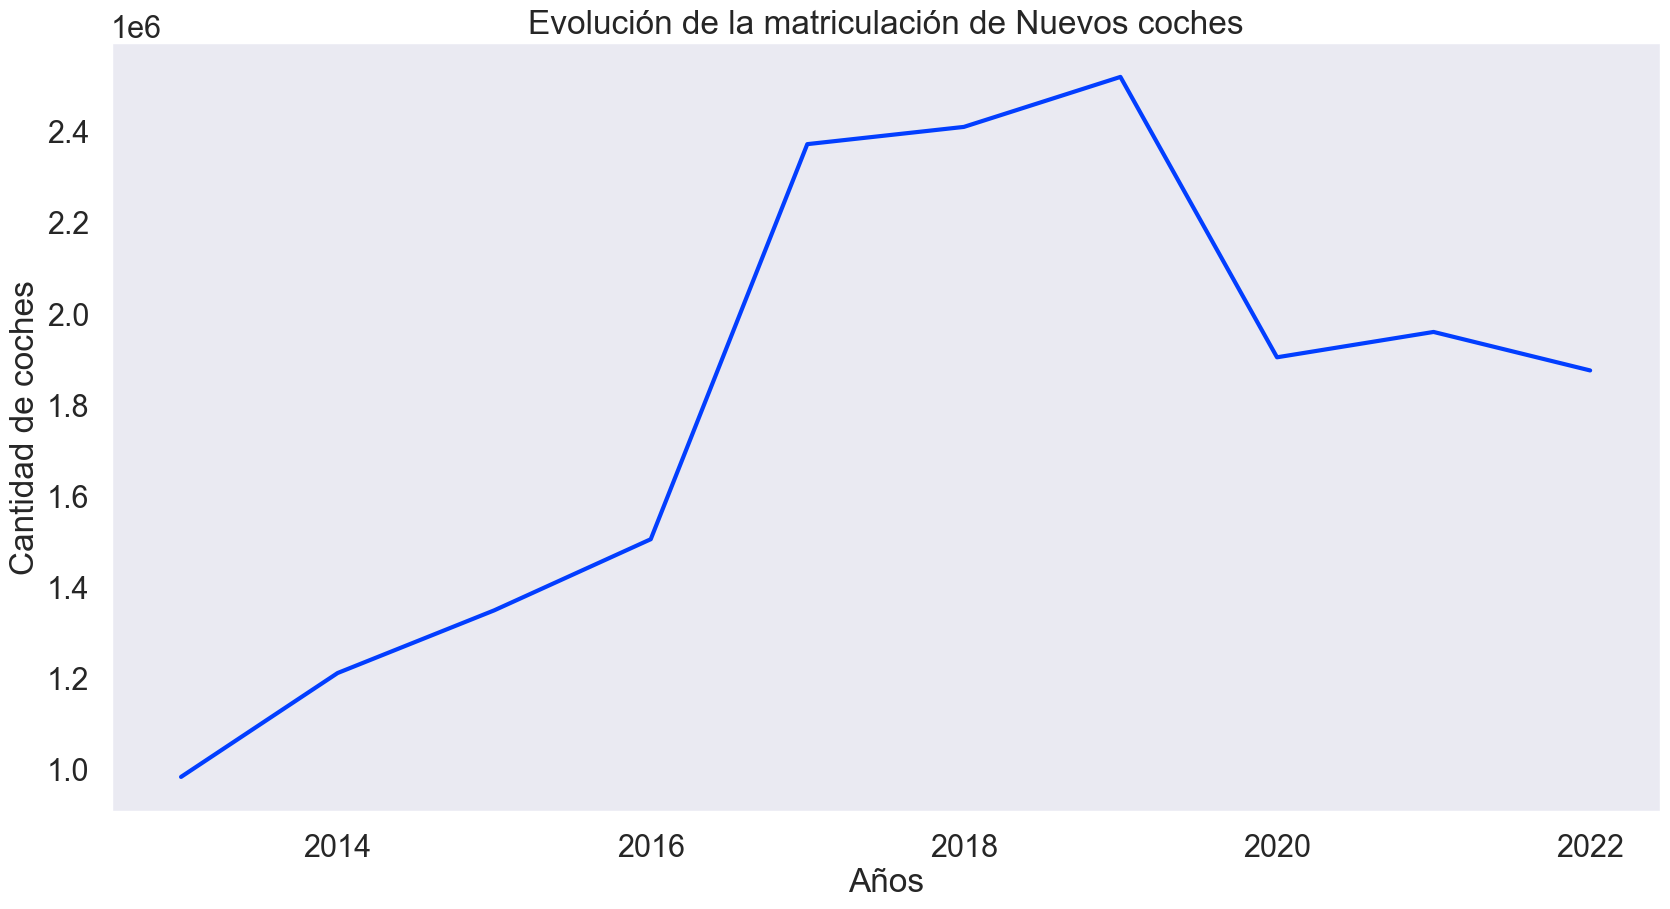

In [48]:
id_vars = ['Años']
value_vars = ['Gas_Bio_y_Bi', 'Eléctricos', 'Gasolina', 'Diesel', 'Otros']
df_long = df_new_cars.melt(id_vars=id_vars, value_vars=value_vars, var_name='Motor', value_name='Cantidad de coches')

plt.figure(figsize=(20, 10))
sns.lineplot(data=df_long, x='Años', y='Cantidad de coches', errorbar=None)
plt.title('Evolución de la matriculación de Nuevos coches')
plt.show()

#### Evolución de los Nuevos coches registrados por tipo de motor

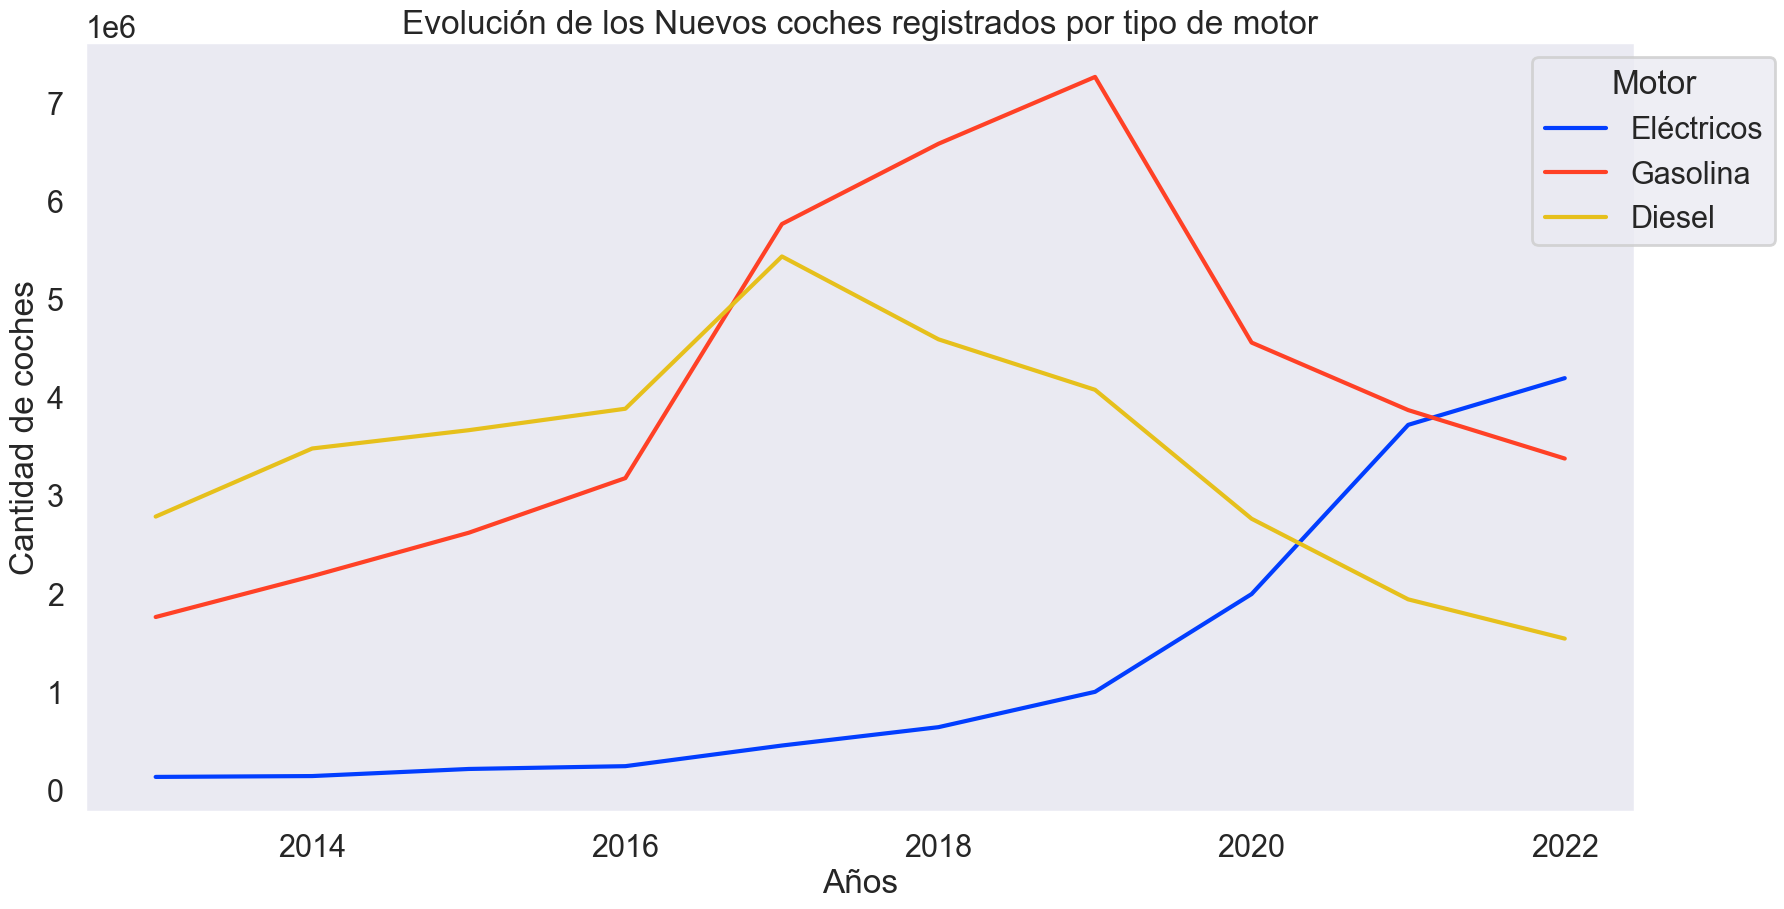

In [49]:
id_vars = 'Años'
value_vars = ['Eléctricos', 'Gasolina', 'Diesel']
custom_palette ={'Eléctricos': '#023eff', 'Gasolina': '#ff4126', 'Diesel': '#e6c01c'}

df_long = df_new_cars.melt(id_vars=id_vars, value_vars=value_vars, var_name='Motor', value_name='Cantidad de coches')

plt.figure(figsize=(20, 10))
sns.lineplot(data=df_long, x='Años', y='Cantidad de coches', hue='Motor', palette=custom_palette)
plt.legend(title='Motor', loc='upper right', bbox_to_anchor=(1.1, 1))
plt.title('Evolución de los Nuevos coches registrados por tipo de motor')
plt.show()

#### Evolución de los nuevos coches eléctricos registrados

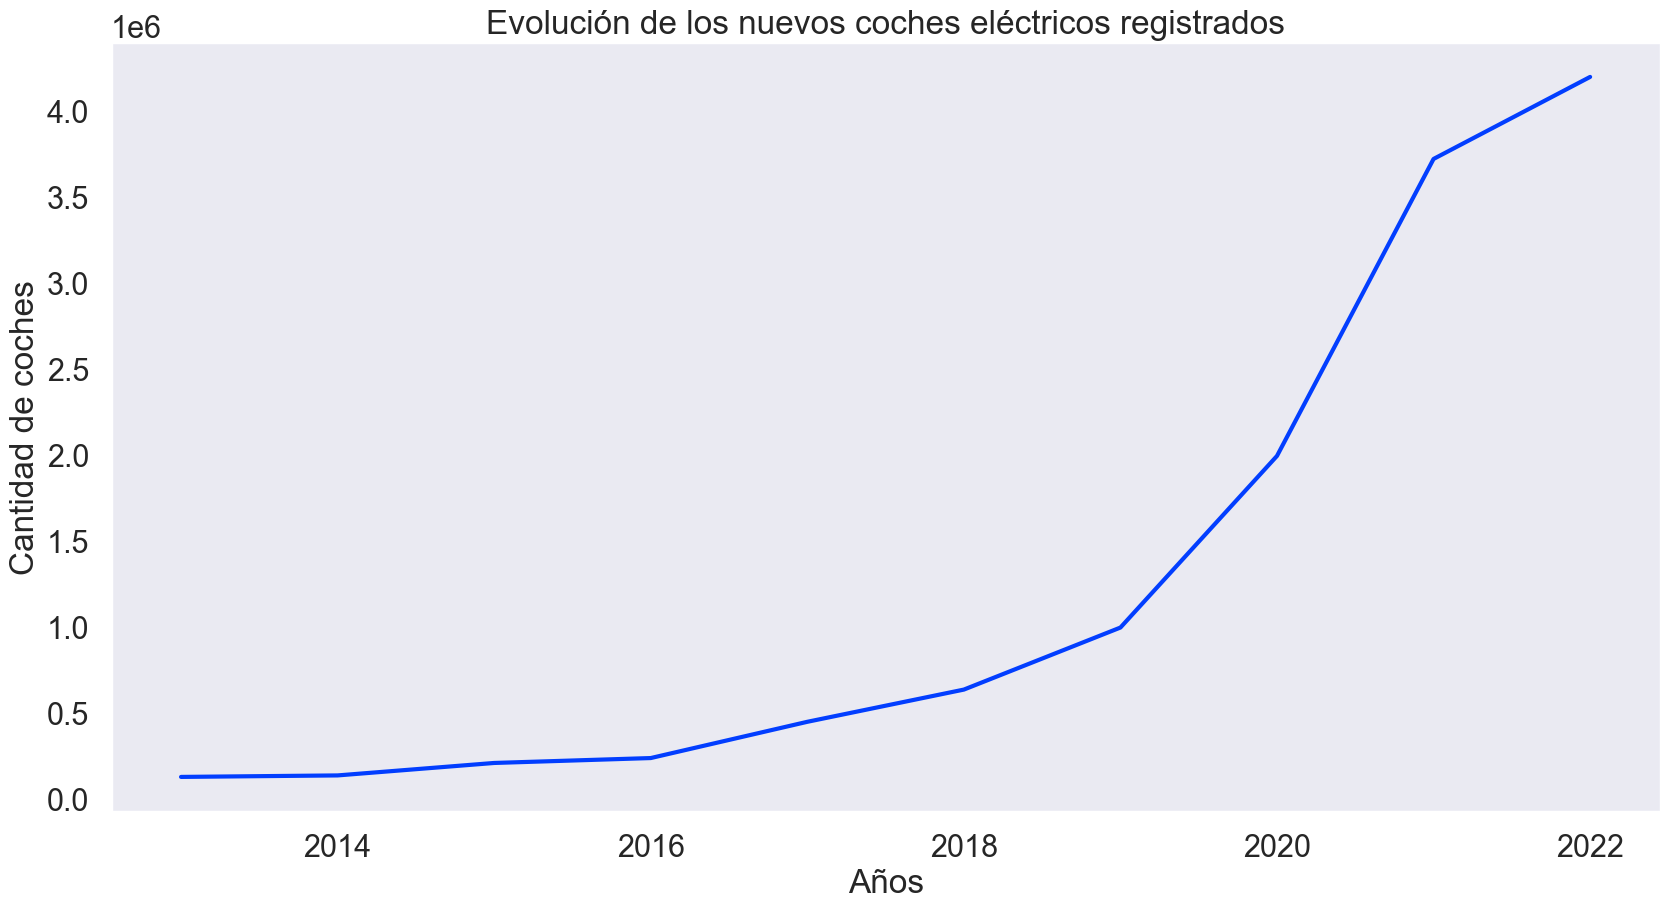

In [50]:
id_vars = ['Años']
value_vars = ['Eléctricos']
df_long = df_new_cars.melt(id_vars=id_vars, value_vars=value_vars, var_name='Motor', value_name='Cantidad de coches')

plt.figure(figsize=(20, 10))
sns.lineplot(data=df_long, x='Años', y='Cantidad de coches', color='#023eff')
plt.title('Evolución de los nuevos coches eléctricos registrados')
plt.show()

#### Comparativa de los nuevos coches registrados y las emisiones por el uso de automóviles

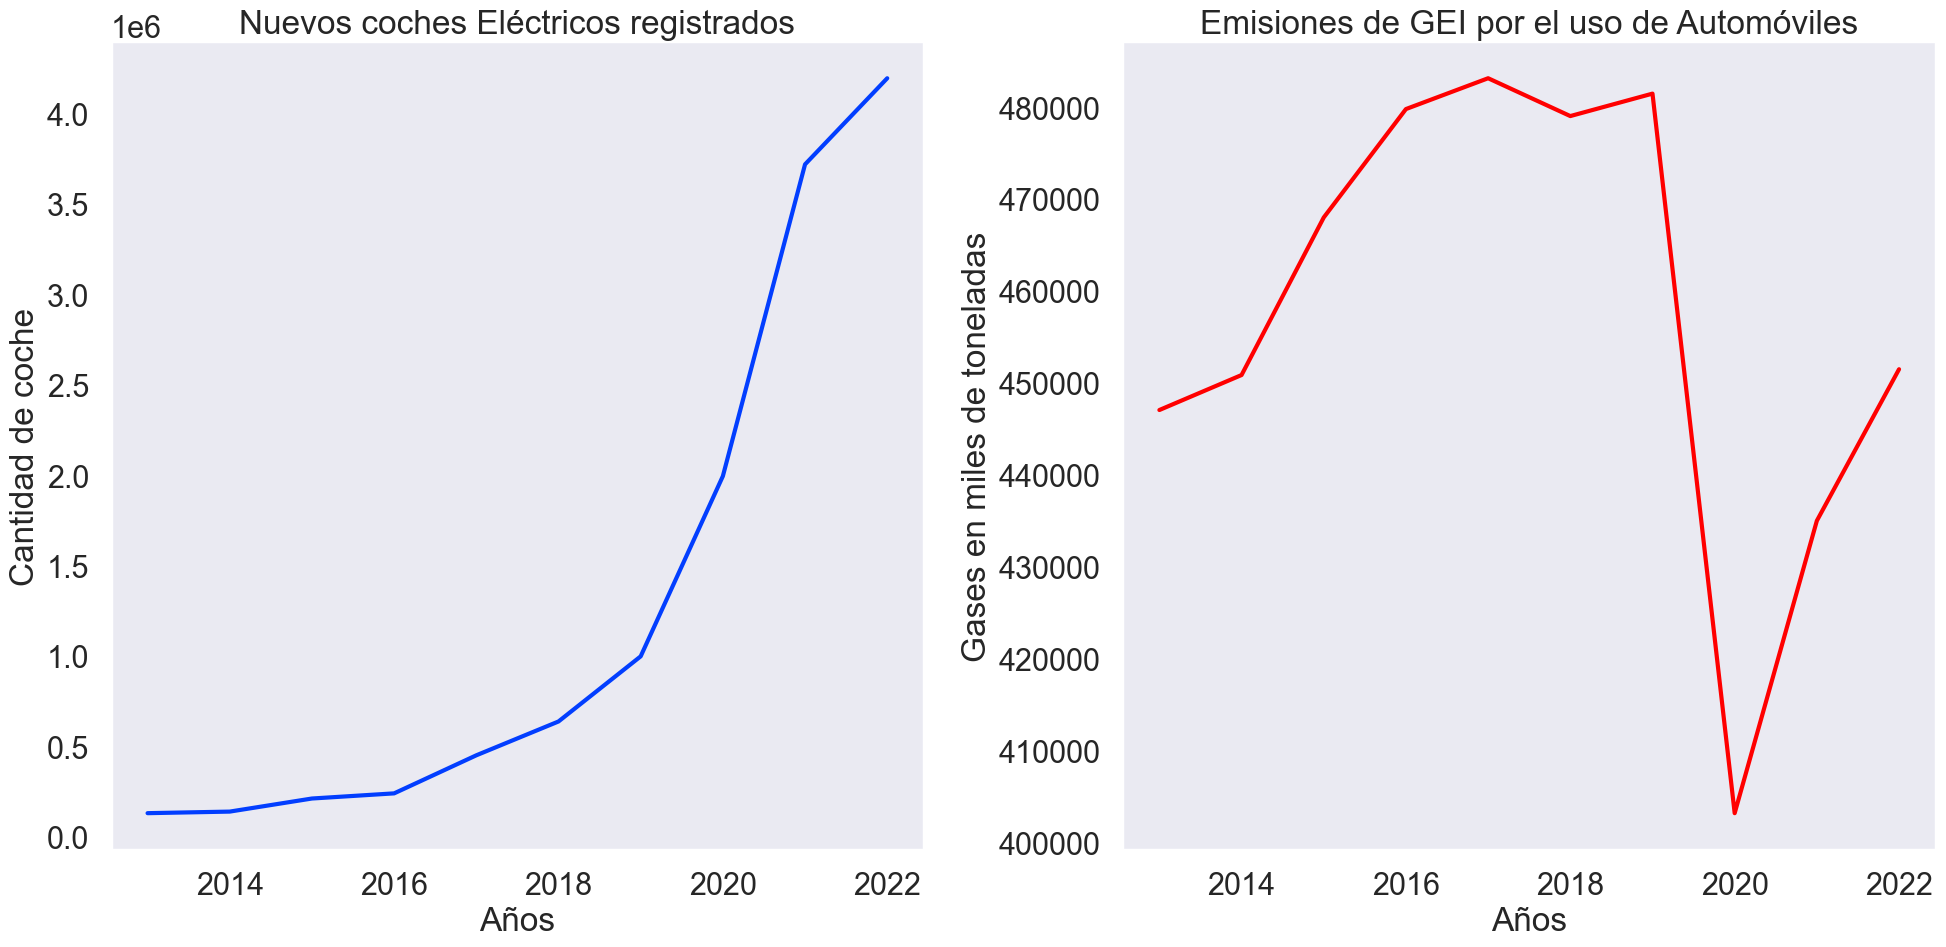

In [51]:
df_evo_elec_x_trans_ghe = df_greenhouse_gases.merge(df_new_cars, how='inner', on='Años').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharex=True)
# Gráfico 1: Evolución de vehículos eléctricos + hidrógeno
sns.lineplot(data=df_evo_elec_x_trans_ghe, x="Años", y="Eléctricos", ax=axes[0], color='#023eff')
axes[0].set_title('Nuevos coches Eléctricos registrados')
axes[0].set_ylabel("Cantidad de coche")

# Gráfico 2: Evolución de automóviles de combustión
sns.lineplot(data=df_evo_elec_x_trans_ghe, x="Años", y="Combustión_en_automóviles", ax=axes[1], color="red")
axes[1].set_title("Emisiones de GEI por el uso de Automóviles")
axes[1].set_ylabel("Gases en miles de toneladas")
plt.tight_layout()
plt.show()

#### Comparativa de los coches eléctricos nuevos matriculados por año y la proporción de anual de coche de combustión interna

In [52]:
df_cars_park_plus_new = df_cars_park.merge(df_new_cars, on=['Años', 'Geocodificación'], how='inner', suffixes=(None, '_nuevos')).reset_index(drop=True)

df_cars_park_plus_new["Porcentaje_Combustión"] = (
(df_cars_park_plus_new["Gasolina"] + df_cars_park_plus_new["Diesel"]) / 
df_cars_park_plus_new[['Gas_Bio_y_Bi', 'Eléctricos', 'Gasolina', 'Diesel', 'Otros']].sum(axis=1) * 100 ).round(2)

df_cars_park_plus_new.head(10)

,Geocodificación,Años,Gas_Bio_y_Bi,Eléctricos,Gasolina,Diesel,Otros,Gas_Bio_y_Bi_nuevos,Eléctricos_nuevos,Gasolina_nuevos,Diesel_nuevos,Otros_nuevos,Porcentaje_Combustión
0,EU27_2020,2013,6931564,281476,67795426,36683521,714507,214898,129552,1759604,2783435,30476,92.95
1,EU27_2020,2014,7140919,451589,76912591,71752025,932856,232953,138254,2176478,3477677,32428,94.58
2,EU27_2020,2015,4363751,826864,66433065,68391653,627710,213570,210601,2618876,3664274,38006,95.86
3,EU27_2020,2016,4506718,1099284,68636414,71210778,694920,174293,239084,3175756,3882988,53711,95.69
4,EU27_2020,2017,4588132,1736458,100676997,90375941,494892,203155,449592,5765771,5435460,6652,96.55
5,EU27_2020,2018,4845350,2420092,106081702,93818922,471622,231732,636714,6584154,4590472,6622,96.27
6,EU27_2020,2019,5072660,3377349,108139562,94010359,471125,252139,997034,7265619,4075878,7526,95.77
7,EU27_2020,2020,5342633,5340394,108405255,93592889,491274,207302,1993783,4557309,2761380,2088,94.76
8,EU27_2020,2021,5554020,8745192,108011923,92399916,533211,268510,3718507,3869164,1939659,4258,93.11
9,EU27_2020,2022,5854719,12440878,110968329,93169033,580317,262278,4194910,3375129,1539521,5829,91.54


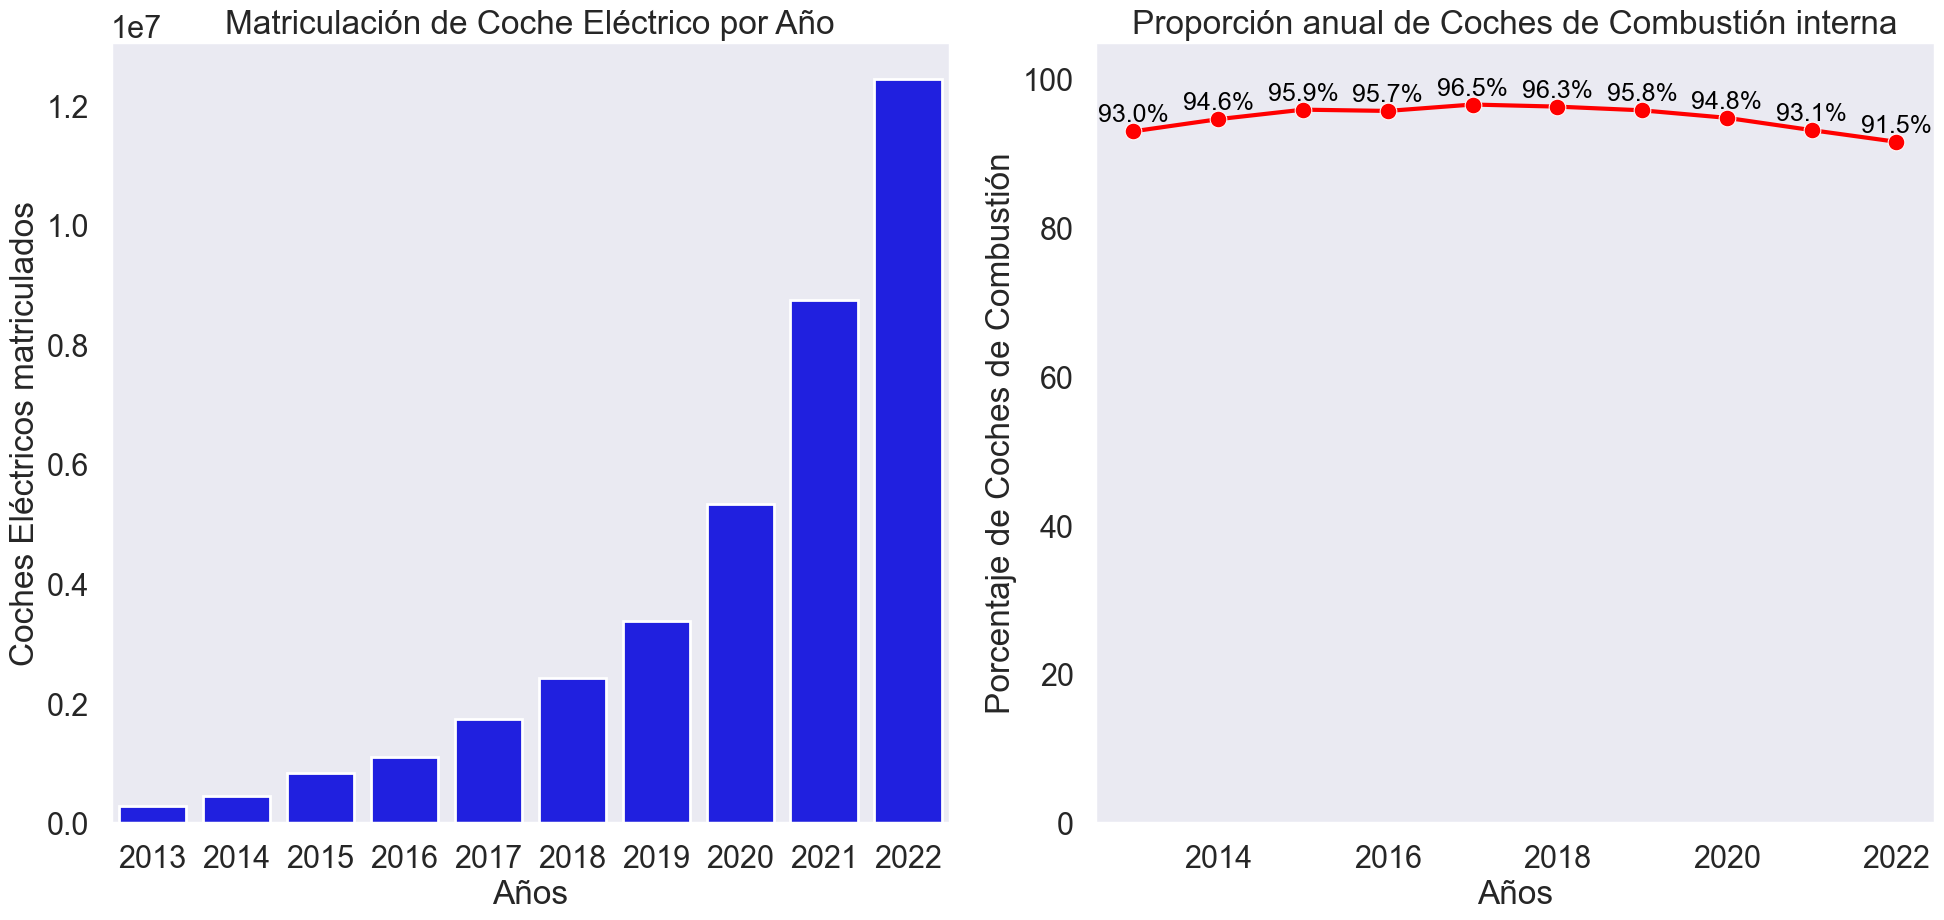

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
sns.barplot(data=df_cars_park_plus_new, x='Años', y='Eléctricos',
            color='blue', ax=ax1)
ax1.set_title('Matriculación de Coche Eléctrico por Año')
ax1.set_ylabel('Coches Eléctricos matriculados')

sns.lineplot(data=df_cars_park_plus_new, x='Años', y='Porcentaje_Combustión',
             color='red', marker='o', ax=ax2)
ax2.set_title('Proporción anual de Coches de Combustión interna')
ax2.set_ylabel('Porcentaje de Coches de Combustión')
ax2.set_ylim(0, 105)

for x, y in zip(df_cars_park_plus_new['Años'], df_cars_park_plus_new['Porcentaje_Combustión']):
    ax2.text(x, y +1.3, f'{y:.1f}%', color='black', fontsize=18, ha='center')

plt.tight_layout()
plt.show()

___
___